## import

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
%ls

drive/  sample_data/


In [4]:
%cd drive/MyDrive/csir

/content/drive/MyDrive/csir


In [ ]:
# # Create kaggle.json manually from your API key
# import json
# import os

# # Replace with your actual values
# kaggle_creds = {
#     "username": "mysteriousavailable",
#     "key": "KGAT_826e7892e299689be1e3faaa725b6e23"
# }

# os.makedirs('/root/.kaggle', exist_ok=True)
# with open('/root/.kaggle/kaggle.json', 'w') as f:
#     json.dump(kaggle_creds, f)

# !chmod 600 /root/.kaggle/kaggle.json

In [ ]:
# Now download
# %pip install kaggle -q

In [ ]:
%kaggle datasets download -d raihansultan/cicids2017 -p /content/cicids2017 --unzip

Dataset URL: https://www.kaggle.com/datasets/raihansultan/cicids2017
License(s): Attribution 4.0 International (CC BY 4.0)
100% 489M/489M [00:03<00:00, 138MB/s]  



## Memory usage too high --> restart from here {caution : dont run above code}

In [ ]:
# CELL 1 — Imports and Load
import pandas as pd
import numpy as np
import os

df = pd.read_parquet('cicids2017_clean.parquet')
print(df.shape)
print(df.columns.tolist())

(2827876, 42)
['Destination Port', 'Flow Duration', 'Total Fwd Packets', 'Total Length of Fwd Packets', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std', 'Bwd Packet Length Min', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Min', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd Packets/s', 'Min Packet Length', 'Packet Length Mean', 'Packet Length Std', 'FIN Flag Count', 'PSH Flag Count', 'ACK Flag Count', 'URG Flag Count', 'Down/Up Ratio', 'Init_Win_bytes_forward', 'Init_Win_bytes_backward', 'act_data_pkt_fwd', 'min_seg_size_forward', 'Active Mean', 'Active Std', 'Idle Std', 'Label', 'binary_label']


In [ ]:
# CELL 2 — Drop zero-variance, duplicates, corrupted columns in-place
drop_round1 = [
    # All-zero bulk features
    'Fwd Avg Bytes/Bulk', 'Fwd Avg Packets/Bulk', 'Fwd Avg Bulk Rate',
    'Bwd Avg Bytes/Bulk', 'Bwd Avg Packets/Bulk', 'Bwd Avg Bulk Rate',
    # Zero/near-zero variance flags
    'Bwd PSH Flags', 'Bwd URG Flags', 'Fwd URG Flags', 'CWE Flag Count',
    # Perfect duplicates
    'Fwd Header Length.1', 'Subflow Fwd Packets', 'Subflow Bwd Packets',
    'Subflow Fwd Bytes', 'Subflow Bwd Bytes', 'Avg Fwd Segment Size',
    'Avg Bwd Segment Size', 'SYN Flag Count',
    # Near-perfect redundancies
    'Fwd IAT Total', 'Fwd IAT Max', 'Average Packet Size',
    'Fwd Packets/s', 'Bwd Packet Length Max', 'Idle Max', 'Idle Min',
    'ECE Flag Count', 'RST Flag Count',
    # Round 2 redundancies
    'Packet Length Variance', 'Max Packet Length', 'Bwd IAT Total',
    'Active Max', 'Active Min',
    # Corrupted (CICFlowMeter overflow)
    'Fwd Header Length', 'Bwd Header Length',
    # Remaining redundancies
    'Total Length of Bwd Packets', 'Total Backward Packets',
    'Fwd Packet Length Max', 'Idle Mean',
]

df.drop(columns=[c for c in drop_round1 if c in df.columns], inplace=True)
print(f"Columns remaining: {df.shape[1]}")

Columns remaining: 42


In [ ]:
# CELL 3 — Label setup and binary label
df['binary_label'] = (df['Label'] != 'BENIGN').astype(np.int8)

print(df['Label'].value_counts())
print(f"\nShape: {df.shape}")

Label
BENIGN                      2271320
DoS_Hulk                     230124
PortScan                     158804
DDoS                         128025
DoS_GoldenEye                 10293
FTPPatator                     7935
SSHPatator                     5897
DoS_slowloris                  5796
DoS_Slowhttptest               5499
Bot                            1956
Web_Attack_Brute_Force         1507
Web_Attack_XSS                  652
Infiltration                     36
Web_Attack_Sql_Injection         21
Heartbleed                       11
Name: count, dtype: int64

Shape: (2827876, 42)


In [ ]:
# CELL 4 — Fix corrupted values (CICFlowMeter overflow artifacts)
feature_cols = [c for c in df.columns if c not in ['Label', 'binary_label']]

bad_cols = {}
for col in feature_cols:
    n_bad = (df[col] < -1e6).sum()
    n_high = (df[col] > 1e9).sum()
    if n_bad > 0 or n_high > 0:
        bad_cols[col] = (n_bad, n_high)
        print(f"{col}: {n_bad} below -1e6, {n_high} above 1e9")

for col in bad_cols:
    p01 = df[col].quantile(0.01)
    p99 = df[col].quantile(0.99)
    df[col].clip(lower=p01, upper=p99, inplace=True)
    print(f"Clipped {col} to [{p01:.2f}, {p99:.2f}]")

X = df[feature_cols].values
print(f"\nAfter fix — NaN: {np.isnan(X).any()}, Inf: {np.isinf(X).any()}")
print(f"Values below -1e6: {(X < -1e6).sum()}")
del X

Flow Bytes/s: 82 below -1e6, 650 above 1e9
Flow Packets/s: 109 below -1e6, 0 above 1e9
min_seg_size_forward: 34 below -1e6, 0 above 1e9
Clipped Flow Bytes/s to [0.00, 12333333.33]


/tmp/ipykernel_2371/1421521103.py:15: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].clip(lower=p01, upper=p99, inplace=True)
/tmp/ipykernel_2371/1421521103.py:15: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', tr

Clipped Flow Packets/s to [0.06, 2000000.00]
Clipped min_seg_size_forward to [20.00, 40.00]


/tmp/ipykernel_2371/1421521103.py:15: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].clip(lower=p01, upper=p99, inplace=True)



After fix — NaN: False, Inf: False
Values below -1e6: 0


In [ ]:
# CELL 5 — Label encoding
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['label_encoded'] = le.fit_transform(df['Label']).astype(np.int8)

print("Label mapping:")
for i, cls in enumerate(le.classes_):
    print(f"  {i:2d} : {cls}  ({(df['label_encoded']==i).sum()})")

Label mapping:
   0 : BENIGN  (2271320)
   1 : Bot  (1956)
   2 : DDoS  (128025)
   3 : DoS_GoldenEye  (10293)
   4 : DoS_Hulk  (230124)
   5 : DoS_Slowhttptest  (5499)
   6 : DoS_slowloris  (5796)
   7 : FTPPatator  (7935)
   8 : Heartbleed  (11)
   9 : Infiltration  (36)
  10 : PortScan  (158804)
  11 : SSHPatator  (5897)
  12 : Web_Attack_Brute_Force  (1507)
  13 : Web_Attack_Sql_Injection  (21)
  14 : Web_Attack_XSS  (652)


In [ ]:
# CELL 6 — Rare class grouping (merge classes with < 100 samples into label 99)
# Heartbleed=11, Infiltration=36, Web_Attack_Sql_Injection=21
rare_labels = ['Heartbleed', 'Infiltration', 'Web_Attack_Sql_Injection']
df['label_grouped'] = df['Label'].apply(
    lambda x: 'Other_Attack' if x in rare_labels else x
)

le_grouped = LabelEncoder()
df['label_grouped_enc'] = le_grouped.fit_transform(df['label_grouped']).astype(np.int8)

print("Grouped label mapping:")
for i, cls in enumerate(le_grouped.classes_):
    print(f"  {i:2d} : {cls}  ({(df['label_grouped_enc']==i).sum()})")

Grouped label mapping:
   0 : BENIGN  (2271320)
   1 : Bot  (1956)
   2 : DDoS  (128025)
   3 : DoS_GoldenEye  (10293)
   4 : DoS_Hulk  (230124)
   5 : DoS_Slowhttptest  (5499)
   6 : DoS_slowloris  (5796)
   7 : FTPPatator  (7935)
   8 : Other_Attack  (68)
   9 : PortScan  (158804)
  10 : SSHPatator  (5897)
  11 : Web_Attack_Brute_Force  (1507)
  12 : Web_Attack_XSS  (652)


In [ ]:
# CELL 7 — Normalize features and save
from sklearn.preprocessing import StandardScaler
import gc

feature_cols = [c for c in df.columns if c not in
                ['Label', 'binary_label', 'label_encoded',
                 'label_grouped', 'label_grouped_enc']]

print(f"Final feature count: {len(feature_cols)}")
print(feature_cols)

scaler = StandardScaler()
df[feature_cols] = scaler.fit_transform(df[feature_cols]).astype(np.float32)

gc.collect()
print(f"Normalized. Shape: {df.shape}")
print(f"Memory usage: {df.memory_usage(deep=True).sum() / 1e9:.2f} GB")

Final feature count: 40
['Destination Port', 'Flow Duration', 'Total Fwd Packets', 'Total Length of Fwd Packets', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std', 'Bwd Packet Length Min', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Min', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd Packets/s', 'Min Packet Length', 'Packet Length Mean', 'Packet Length Std', 'FIN Flag Count', 'PSH Flag Count', 'ACK Flag Count', 'URG Flag Count', 'Down/Up Ratio', 'Init_Win_bytes_forward', 'Init_Win_bytes_backward', 'act_data_pkt_fwd', 'min_seg_size_forward', 'Active Mean', 'Active Std', 'Idle Std']
Normalized. Shape: (2827876, 45)
Memory usage: 0.77 GB


In [ ]:
# CELL 8 — Save final clean normalized dataset
df.to_parquet('cicids2017_final.parquet', index=False)

# Save scaler and label encoders for later use
import joblib
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(le, 'label_encoder.pkl')
joblib.dump(le_grouped, 'label_encoder_grouped.pkl')

print("Saved: cicids2017_final.parquet, scaler.pkl, label_encoder*.pkl")
print(f"Final shape: {df.shape}")
print(f"Features: {len(feature_cols)}")

Saved: cicids2017_final.parquet, scaler.pkl, label_encoder*.pkl
Final shape: (2827876, 45)
Features: 40


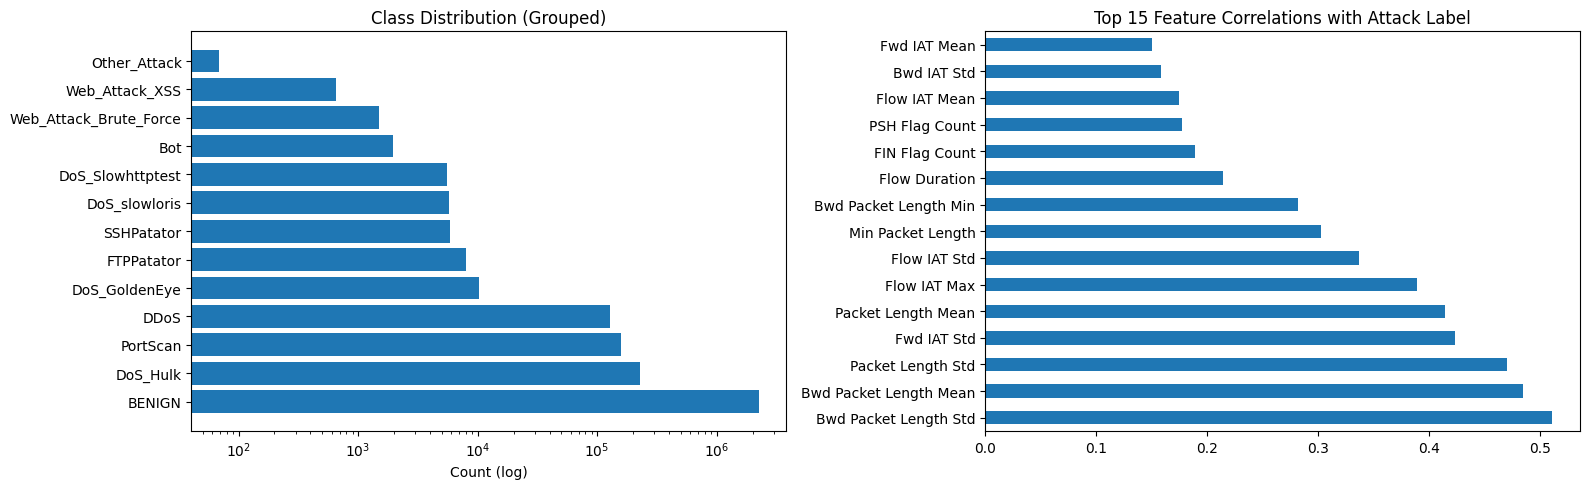

Plot saved.


In [ ]:
# CELL 9 — EDA summary plots (optional, run if GPU RAM allows)
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Class distribution
counts = df['label_grouped'].value_counts()
axes[0].barh(counts.index, counts.values)
axes[0].set_title('Class Distribution (Grouped)')
axes[0].set_xlabel('Count (log)')
axes[0].set_xscale('log')

# Top 15 feature correlations with binary label
corrs = df[feature_cols].corrwith(df['binary_label'].astype(float)).abs()
corrs.sort_values(ascending=False).head(15).plot(kind='barh', ax=axes[1])
axes[1].set_title('Top 15 Feature Correlations with Attack Label')

plt.tight_layout()
plt.savefig('eda_summary.png', dpi=150)
plt.show()
print("Plot saved.")

In [ ]:
# CELL 10 — Clean reinstall matched to torch 2.11 + cu128

# This is the correct package for CUDA 12.x on Colab
%pip install faiss-gpu-cu12 --extra-index-url https://pypi.nvidia.com -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.4/48.4 MB 15.7 MB/s eta 0:00:00


In [ ]:
!pip install torch_geometric -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 65.0 MB/s eta 0:00:00


In [ ]:
# CELL 10b — Verify GPU FAISS
import importlib, faiss
importlib.reload(faiss)

print(dir(faiss))  # check if StandardGpuResources is listed
print(faiss.__version__)

try:
    res = faiss.StandardGpuResources()
    print("FAISS GPU: OK")
except AttributeError:
    print("FAISS GPU not available — will use CPU index with GPU pytorch")

['APPROX_TOPK_BUCKETS_B16_D2', 'APPROX_TOPK_BUCKETS_B32_D2', 'APPROX_TOPK_BUCKETS_B8_D2', 'APPROX_TOPK_BUCKETS_B8_D3', 'AdditiveCoarseQuantizer', 'AdditiveQuantizer', 'AlignedTableFloat32', 'AlignedTableUint16', 'AlignedTableUint8', 'AlignedTable_to_array', 'AllocInfo', 'AllocRequest', 'ArrayInvertedLists', 'ArrayInvertedListsPanorama', 'AutoTuneCriterion', 'BinaryInvertedListScanner', 'BitstringReader', 'BitstringWriter', 'BlockInvertedLists', 'BufferList', 'BufferedIOReader', 'BufferedIOWriter', 'ByteVector', 'ByteVectorVector', 'CMax_float_partition_fuzzy', 'CMax_uint16_partition_fuzzy', 'CMin_float_partition_fuzzy', 'CMin_uint16_partition_fuzzy', 'CenteringTransform', 'CharVector', 'Cloner', 'Clustering', 'Clustering1D', 'ClusteringInitMethod_AFK_MC2', 'ClusteringInitMethod_KMEANS_PLUS_PLUS', 'ClusteringInitMethod_RANDOM', 'ClusteringInitialization', 'ClusteringIterationStats', 'ClusteringIterationStatsVector', 'ClusteringParameters', 'CodePacker', 'CodePackerFlat', 'CodeSet', 'Com

In [ ]:
# CELL 11 — Load final data
import pandas as pd
import numpy as np
import gc

df = pd.read_parquet('cicids2017_final.parquet')

feature_cols = [c for c in df.columns if c not in
                ['Label', 'binary_label', 'label_encoded',
                 'label_grouped', 'label_grouped_enc']]

X = df[feature_cols].values.astype(np.float32)  # (2827876, 40)
y = df['label_grouped_enc'].values.astype(np.int64)
y_binary = df['binary_label'].values.astype(np.int64)

print(f"X: {X.shape}, y: {y.shape}")
print(f"Unique classes: {np.unique(y)}")

X: (2827876, 40), y: (2827876,)
Unique classes: [ 0  1  2  3  4  5  6  7  8  9 10 11 12]


In [ ]:
# CELL 12 — Stratified subsample (RAM-safe for Colab)
# Full 2.8M graph needs ~40GB RAM for edge construction
# We use 300K stratified sample for training graph
# You can increase if using A100

from sklearn.model_selection import train_test_split

SAMPLE_SIZE = 300_000  # adjust up if RAM allows

# Stratified sample to preserve class ratios
idx = np.arange(len(X))
_, sample_idx = train_test_split(
    idx,
    test_size=SAMPLE_SIZE,
    stratify=y,
    random_state=42
)

X_sample = X[sample_idx].copy()
y_sample = y[sample_idx].copy()

print(f"Sample shape: {X_sample.shape}")
print(f"Class distribution in sample:")
unique, counts = np.unique(y_sample, return_counts=True)
import joblib
le_grouped = joblib.load('label_encoder_grouped.pkl')
for u, c in zip(unique, counts):
    print(f"  {le_grouped.classes_[u]}: {c}")

del X, idx
gc.collect()

Sample shape: (300000, 40)
Class distribution in sample:
  BENIGN: 240957
  Bot: 207
  DDoS: 13582
  DoS_GoldenEye: 1092
  DoS_Hulk: 24413
  DoS_Slowhttptest: 583
  DoS_slowloris: 615
  FTPPatator: 842
  Other_Attack: 7
  PortScan: 16847
  SSHPatator: 626
  Web_Attack_Brute_Force: 160
  Web_Attack_XSS: 69


38

In [ ]:
# CELL 13 — Build k-NN graph using FAISS
import faiss

K = 7  # neighbors per node (excluding self)

d = X_sample.shape[1]  # 40

# Use GPU index if available, else CPU
try:
    res = faiss.StandardGpuResources()
    index = faiss.IndexFlatIP(d)  # Inner product = cosine sim on normalized vectors
    index = faiss.index_cpu_to_gpu(res, 0, index)
    print("Using GPU FAISS")
except:
    index = faiss.IndexFlatIP(d)
    print("Using CPU FAISS")

# L2-normalize for cosine similarity via inner product
norms = np.linalg.norm(X_sample, axis=1, keepdims=True)
norms[norms == 0] = 1e-8
X_norm = (X_sample / norms).astype(np.float32)

index.add(X_norm)
print(f"Index built with {index.ntotal} vectors")

# Search k+1 because first result is always the node itself
distances, indices = index.search(X_norm, K + 1)
print(f"Search done. indices shape: {indices.shape}")

Using GPU FAISS
Index built with 300000 vectors
Search done. indices shape: (300000, 8)


In [ ]:
# CELL 14 — Build edge index (PyG format)
# Remove self-loops (first column of indices is always self)
src_list = []
dst_list = []

for i in range(len(X_sample)):
    for j in range(1, K + 1):  # skip col 0 (self)
        neighbor = indices[i, j]
        if neighbor != i and neighbor >= 0:
            src_list.append(i)
            dst_list.append(neighbor)

src = np.array(src_list, dtype=np.int64)
dst = np.array(dst_list, dtype=np.int64)

print(f"Edges (directed): {len(src)}")
print(f"Edges (approx per node): {len(src)/len(X_sample):.1f}")

del src_list, dst_list, distances, indices, X_norm
gc.collect()

Edges (directed): 2037463
Edges (approx per node): 6.8


0

In [ ]:
# CELL 15 — Build PyTorch Geometric Data object
import torch
from torch_geometric.data import Data

edge_index = torch.tensor(np.stack([src, dst], axis=0), dtype=torch.long)
x = torch.tensor(X_sample, dtype=torch.float32)
y_tensor = torch.tensor(y_sample, dtype=torch.long)

data = Data(x=x, edge_index=edge_index, y=y_tensor)
data.num_classes = len(le_grouped.classes_)

print(data)
print(f"Num nodes: {data.num_nodes}")
print(f"Num edges: {data.num_edges}")
print(f"Num features: {data.num_node_features}")
print(f"Num classes: {data.num_classes}")

del src, dst, x, edge_index, y_tensor
gc.collect()

Data(x=[300000, 40], edge_index=[2, 2037463], y=[300000], num_classes=13)
Num nodes: 300000
Num edges: 2037463
Num features: 40
Num classes: 13


36

In [ ]:
# CELL 16 — Train/val/test masks (stratified)
from torch_geometric.transforms import RandomNodeSplit

n = data.num_nodes
perm = torch.randperm(n)

train_end = int(0.7 * n)
val_end   = int(0.85 * n)

train_mask = torch.zeros(n, dtype=torch.bool)
val_mask   = torch.zeros(n, dtype=torch.bool)
test_mask  = torch.zeros(n, dtype=torch.bool)

train_mask[perm[:train_end]]      = True
val_mask[perm[train_end:val_end]] = True
test_mask[perm[val_end:]]         = True

data.train_mask = train_mask
data.val_mask   = val_mask
data.test_mask  = test_mask

print(f"Train: {train_mask.sum().item()}, Val: {val_mask.sum().item()}, Test: {test_mask.sum().item()}")

# Save graph
torch.save(data, 'cicids_graph.pt')
print("Graph saved to cicids_graph.pt")

Train: 210000, Val: 45000, Test: 45000
Graph saved to cicids_graph.pt


In [ ]:
# CELL 17 — Verify graph health
from torch_geometric.utils import is_undirected, contains_self_loops, contains_isolated_nodes

print(f"Self loops:      {contains_self_loops(data.edge_index)}")
print(f"Isolated nodes:  {contains_isolated_nodes(data.edge_index, data.num_nodes)}")
print(f"Is undirected:   {is_undirected(data.edge_index)}")
print(f"x NaN:           {data.x.isnan().any().item()}")
print(f"x Inf:           {data.x.isinf().any().item()}")
print(f"Edge index max:  {data.edge_index.max().item()} (should be < {data.num_nodes})")

Self loops:      False
Isolated nodes:  False
Is undirected:   False
x NaN:           False
x Inf:           False
Edge index max:  299999 (should be < 300000)


In [ ]:
# CELL 18 — GNN Architecture
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import SAGEConv, BatchNorm

class CyberSAGE(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, num_layers=3, dropout=0.3):
        super().__init__()

        self.convs = nn.ModuleList()
        self.bns   = nn.ModuleList()

        # Input layer
        self.convs.append(SAGEConv(in_channels, hidden_channels))
        self.bns.append(BatchNorm(hidden_channels))

        # Hidden layers
        for _ in range(num_layers - 2):
            self.convs.append(SAGEConv(hidden_channels, hidden_channels))
            self.bns.append(BatchNorm(hidden_channels))

        # Output layer
        self.convs.append(SAGEConv(hidden_channels, hidden_channels))
        self.bns.append(BatchNorm(hidden_channels))

        # Skip connection projection (in -> hidden)
        self.skip = nn.Linear(in_channels, hidden_channels)

        # Classifier head
        self.classifier = nn.Sequential(
            nn.Linear(hidden_channels, hidden_channels // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_channels // 2, out_channels)
        )

        self.dropout = dropout

    def forward(self, x, edge_index):
        skip = self.skip(x)

        for i, (conv, bn) in enumerate(zip(self.convs, self.bns)):
            x = conv(x, edge_index)
            x = bn(x)
            x = F.relu(x)
            x = F.dropout(x, p=self.dropout, training=self.training)

        x = x + skip  # residual connection
        return self.classifier(x)


model = CyberSAGE(
    in_channels=40,
    hidden_channels=128,
    out_channels=data.num_classes,
    num_layers=3,
    dropout=0.3
)

print(model)
total_params = sum(p.numel() for p in model.parameters())
print(f"\nTotal parameters: {total_params:,}")

CyberSAGE(
  (convs): ModuleList(
    (0): SAGEConv(40, 128, aggr=mean)
    (1-2): 2 x SAGEConv(128, 128, aggr=mean)
  )
  (bns): ModuleList(
    (0-2): 3 x BatchNorm(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (skip): Linear(in_features=40, out_features=128, bias=True)
  (classifier): Sequential(
    (0): Linear(in_features=128, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=64, out_features=13, bias=True)
  )
)

Total parameters: 91,277


In [ ]:
# CELL 19 — Class weights for imbalance
import numpy as np
from sklearn.utils.class_weight import compute_class_weight

classes = np.unique(y_sample)
weights = compute_class_weight('balanced', classes=classes, y=y_sample)
class_weights = torch.tensor(weights, dtype=torch.float32)

print("Class weights:")
for i, (cls, w) in enumerate(zip(le_grouped.classes_, weights)):
    print(f"  {cls:<30} {w:.4f}")

Class weights:
  BENIGN                         0.0958
  Bot                            111.4827
  DDoS                           1.6991
  DoS_GoldenEye                  21.1327
  DoS_Hulk                       0.9453
  DoS_Slowhttptest               39.5831
  DoS_slowloris                  37.5235
  FTPPatator                     27.4073
  Other_Attack                   3296.7033
  PortScan                       1.3698
  SSHPatator                     36.8641
  Web_Attack_Brute_Force         144.2308
  Web_Attack_XSS                 334.4482


In [ ]:
# CELL 20 — Training setup
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using: {device}")

data = data.to(device)
model = model.to(device)
class_weights = class_weights.to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5)
criterion = nn.CrossEntropyLoss(weight=class_weights)

Using: cuda


In [ ]:
# CELL 21 — Training loop
from sklearn.metrics import f1_score
import time

def train_epoch():
    model.train()
    optimizer.zero_grad()
    out = model(data.x, data.edge_index)
    loss = criterion(out[data.train_mask], data.y[data.train_mask])
    loss.backward()
    optimizer.step()
    return loss.item()

@torch.no_grad()
def evaluate(mask):
    model.eval()
    out = model(data.x, data.edge_index)
    loss = criterion(out[mask], data.y[mask]).item()
    pred = out[mask].argmax(dim=1).cpu().numpy()
    true = data.y[mask].cpu().numpy()
    f1 = f1_score(true, pred, average='macro', zero_division=0)
    acc = (pred == true).mean()
    return loss, acc, f1

EPOCHS = 200
best_val_f1 = 0
patience_counter = 0
EARLY_STOP_PATIENCE = 20

print(f"{'Epoch':>6} {'Train Loss':>12} {'Val Loss':>10} {'Val Acc':>9} {'Val F1':>8} {'Time':>7}")
print("-" * 60)

for epoch in range(1, EPOCHS + 1):
    t = time.time()
    train_loss = train_epoch()
    val_loss, val_acc, val_f1 = evaluate(data.val_mask)
    scheduler.step(val_loss)

    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        torch.save(model.state_dict(), 'best_model.pt')
        patience_counter = 0
    else:
        patience_counter += 1

    print(f"{epoch:>6} {train_loss:>12.4f} {val_loss:>10.4f} {val_acc:>9.4f} {val_f1:>8.4f} {time.time()-t:>6.1f}s")

    if patience_counter >= EARLY_STOP_PATIENCE:
        print(f"\nEarly stopping at epoch {epoch}")
        break

print(f"\nBest Val F1: {best_val_f1:.4f}")

 Epoch   Train Loss   Val Loss   Val Acc   Val F1    Time
------------------------------------------------------------
     1       0.6113     0.8719    0.6398   0.3104    0.4s
     2       0.6209     0.8659    0.6438   0.3118    0.3s
     3       0.6106     0.8604    0.6472   0.3125    0.3s
     4       0.5747     0.8548    0.6513   0.3134    0.3s
     5       0.5376     0.8488    0.6539   0.3147    0.3s
     6       0.5387     0.8406    0.6582   0.3165    0.3s
     7       0.5386     0.8330    0.6632   0.3194    0.3s
     8       0.5100     0.8252    0.6679   0.3211    0.3s
     9       0.5120     0.8183    0.6736   0.3222    0.3s
    10       0.4931     0.8128    0.6805   0.3247    0.3s
    11       0.4956     0.8083    0.6863   0.3265    0.3s
    12       0.4979     0.8054    0.6917   0.3285    0.3s
    13       0.4663     0.8039    0.6953   0.3304    0.3s
    14       0.4696     0.8016    0.7017   0.3328    0.3s
    15       0.4572     0.7981    0.7071   0.3350    0.3s
    16     

                        precision    recall  f1-score   support

                BENIGN       1.00      0.77      0.87     36251
                   Bot       0.01      0.96      0.02        25
                  DDoS       0.61      0.99      0.76      1997
         DoS_GoldenEye       0.19      0.97      0.32       151
              DoS_Hulk       0.75      0.99      0.85      3667
      DoS_Slowhttptest       0.24      0.91      0.38        92
         DoS_slowloris       0.15      0.90      0.26        83
            FTPPatator       0.23      0.98      0.37       123
          Other_Attack       0.00      0.50      0.00         2
              PortScan       0.83      0.99      0.90      2490
            SSHPatator       0.11      1.00      0.20        91
Web_Attack_Brute_Force       0.02      0.21      0.04        14
        Web_Attack_XSS       0.06      0.93      0.11        14

              accuracy                           0.81     45000
             macro avg       0.32     

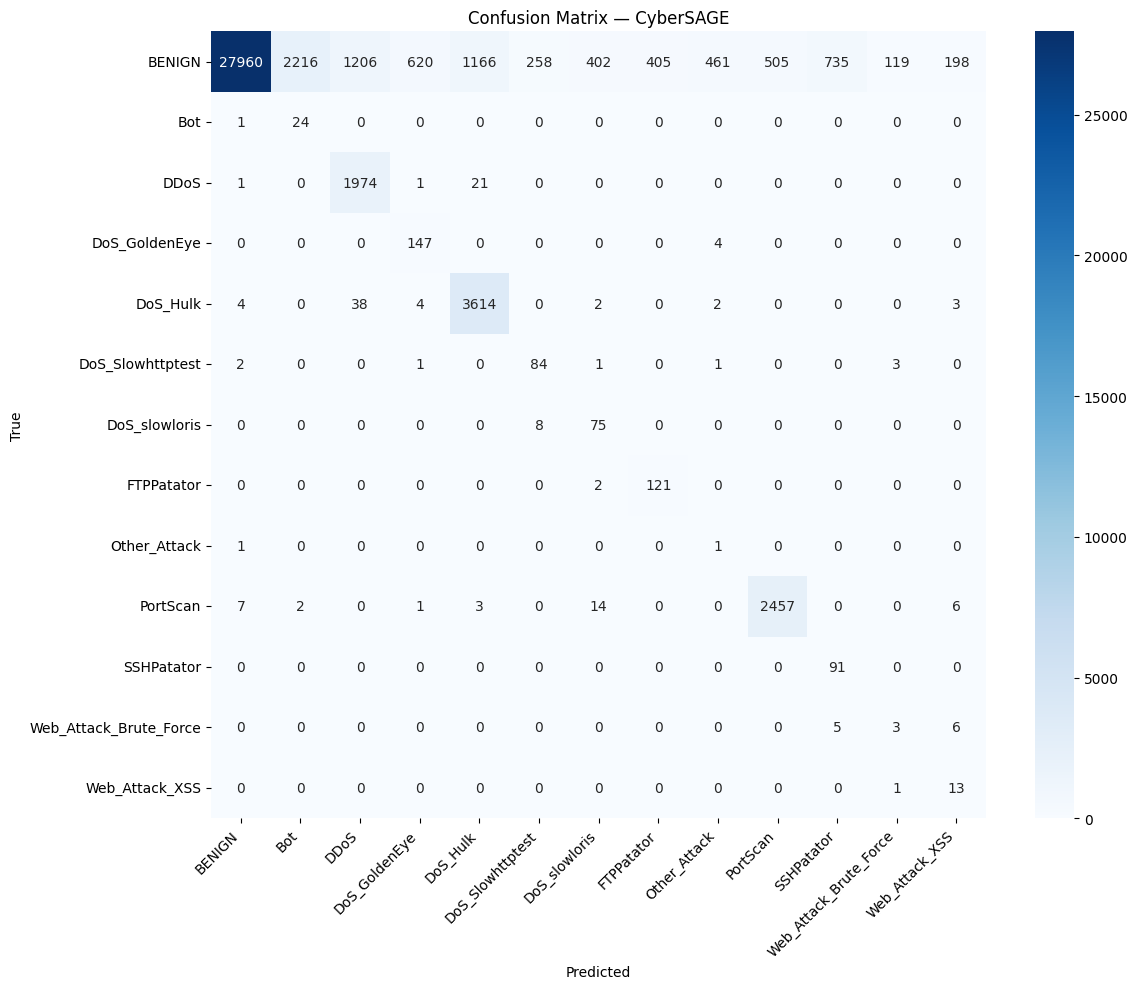

In [ ]:
# CELL 22 — Final evaluation on test set
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

model.load_state_dict(torch.load('best_model.pt'))
model.eval()

with torch.no_grad():
    out = model(data.x, data.edge_index)
    pred = out[data.test_mask].argmax(dim=1).cpu().numpy()
    true = data.y[data.test_mask].cpu().numpy()

print(classification_report(true, pred, target_names=le_grouped.classes_, zero_division=0))

# Confusion matrix
cm = confusion_matrix(true, pred)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=le_grouped.classes_,
            yticklabels=le_grouped.classes_, cmap='Blues')
plt.title('Confusion Matrix — CyberSAGE')
plt.ylabel('True')
plt.xlabel('Predicted')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

In [ ]:
# CELL 23 — Diagnose prediction distribution
import torch
import numpy as np
from collections import Counter

model.load_state_dict(torch.load('best_model.pt'))
model.eval()

with torch.no_grad():
    out = model(data.x, data.edge_index)
    pred_all = out[data.test_mask].argmax(dim=1).cpu().numpy()
    true_all = data.y[data.test_mask].cpu().numpy()

print("Predicted class distribution:")
pred_counts = Counter(pred_all)
for cls_idx, count in sorted(pred_counts.items(), key=lambda x: -x[1]):
    print(f"  {le_grouped.classes_[cls_idx]:<30} predicted: {count}")

print("\nTrue class distribution:")
true_counts = Counter(true_all)
for cls_idx, count in sorted(true_counts.items(), key=lambda x: -x[1]):
    print(f"  {le_grouped.classes_[cls_idx]:<30} true: {count}")

Predicted class distribution:
  BENIGN                         predicted: 27976
  DoS_Hulk                       predicted: 4804
  DDoS                           predicted: 3218
  PortScan                       predicted: 2962
  Bot                            predicted: 2242
  SSHPatator                     predicted: 831
  DoS_GoldenEye                  predicted: 774
  FTPPatator                     predicted: 526
  DoS_slowloris                  predicted: 496
  Other_Attack                   predicted: 469
  DoS_Slowhttptest               predicted: 350
  Web_Attack_XSS                 predicted: 226
  Web_Attack_Brute_Force         predicted: 126

True class distribution:
  BENIGN                         true: 36251
  DoS_Hulk                       true: 3667
  PortScan                       true: 2490
  DDoS                           true: 1997
  DoS_GoldenEye                  true: 151
  FTPPatator                     true: 123
  DoS_Slowhttptest               true: 92
  SSHPata

In [ ]:
# CELL 24 — Fix 1: Reduce class weight strength (main culprit)
# Instead of full 'balanced', use sqrt-dampened weights
from sklearn.utils.class_weight import compute_class_weight

classes = np.unique(y_sample)
raw_weights = compute_class_weight('balanced', classes=classes, y=y_sample)

# Dampen extreme weights — prevents minority classes from dominating
dampened_weights = np.sqrt(raw_weights)
dampened_weights = dampened_weights / dampened_weights.mean()  # normalize around 1.0

print("Raw vs dampened weights:")
for i, cls in enumerate(le_grouped.classes_):
    print(f"  {cls:<30} raw={raw_weights[i]:.2f}  dampened={dampened_weights[i]:.2f}")

class_weights = torch.tensor(dampened_weights, dtype=torch.float32).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights)

Raw vs dampened weights:
  BENIGN                         raw=0.10  dampened=0.03
  Bot                            raw=111.48  dampened=1.05
  DDoS                           raw=1.70  dampened=0.13
  DoS_GoldenEye                  raw=21.13  dampened=0.46
  DoS_Hulk                       raw=0.95  dampened=0.10
  DoS_Slowhttptest               raw=39.58  dampened=0.63
  DoS_slowloris                  raw=37.52  dampened=0.61
  FTPPatator                     raw=27.41  dampened=0.52
  Other_Attack                   raw=3296.70  dampened=5.73
  PortScan                       raw=1.37  dampened=0.12
  SSHPatator                     raw=36.86  dampened=0.61
  Web_Attack_Brute_Force         raw=144.23  dampened=1.20
  Web_Attack_XSS                 raw=334.45  dampened=1.82


In [ ]:
# CELL 25 — Fix 2: Rebuild graph with separate per-class subgraphs
# Attack flows should connect primarily to same-class neighbors
# Strategy: build k-NN within label groups, then add cross-group edges only for BENIGN

import faiss
import gc

BENIGN_IDX = int(np.where(le_grouped.classes_ == 'BENIGN')[0][0])
K_SAME  = 5   # edges within same class
K_CROSS = 2   # edges to BENIGN neighborhood (for context)

src_list, dst_list = [], []

# Per-class k-NN edges
norms = np.linalg.norm(X_sample, axis=1, keepdims=True)
norms[norms == 0] = 1e-8
X_norm = (X_sample / norms).astype(np.float32)

unique_classes = np.unique(y_sample)
for cls in unique_classes:
    cls_idx = np.where(y_sample == cls)[0]
    if len(cls_idx) < 2:
        continue

    X_cls = X_norm[cls_idx]
    d = X_cls.shape[1]
    index = faiss.IndexFlatIP(d)
    index.add(X_cls)

    k = min(K_SAME + 1, len(cls_idx))
    _, neighbors = index.search(X_cls, k)

    for local_i, global_i in enumerate(cls_idx):
        for j in range(1, k):
            local_neighbor = neighbors[local_i, j]
            if local_neighbor >= 0 and local_neighbor < len(cls_idx):
                global_neighbor = cls_idx[local_neighbor]
                src_list.append(global_i)
                dst_list.append(global_neighbor)

    print(f"  {le_grouped.classes_[cls]}: {len(cls_idx)} nodes, edges added")

# Cross edges: each non-BENIGN node gets K_CROSS edges into BENIGN space
benign_idx = np.where(y_sample == BENIGN_IDX)[0]
X_benign = X_norm[benign_idx]
index_benign = faiss.IndexFlatIP(X_benign.shape[1])
index_benign.add(X_benign)

attack_idx = np.where(y_sample != BENIGN_IDX)[0]
_, benign_neighbors = index_benign.search(X_norm[attack_idx], K_CROSS)

for local_i, global_i in enumerate(attack_idx):
    for j in range(K_CROSS):
        bn = benign_neighbors[local_i, j]
        if bn >= 0 and bn < len(benign_idx):
            src_list.append(global_i)
            dst_list.append(benign_idx[bn])

print(f"\nTotal edges: {len(src_list)}")
del X_norm, index, index_benign
gc.collect()

  BENIGN: 240957 nodes, edges added
  Bot: 207 nodes, edges added
  DDoS: 13582 nodes, edges added
  DoS_GoldenEye: 1092 nodes, edges added
  DoS_Hulk: 24413 nodes, edges added
  DoS_Slowhttptest: 583 nodes, edges added
  DoS_slowloris: 615 nodes, edges added
  FTPPatator: 842 nodes, edges added
  Other_Attack: 7 nodes, edges added
  PortScan: 16847 nodes, edges added
  SSHPatator: 626 nodes, edges added
  Web_Attack_Brute_Force: 160 nodes, edges added
  Web_Attack_XSS: 69 nodes, edges added

Total edges: 1618086


31530

In [ ]:
# CELL 26 — Rebuild Data object with new graph
src = np.array(src_list, dtype=np.int64)
dst = np.array(dst_list, dtype=np.int64)

edge_index = torch.tensor(np.stack([src, dst], axis=0), dtype=torch.long)
x = torch.tensor(X_sample, dtype=torch.float32)
y_tensor = torch.tensor(y_sample, dtype=torch.long)

data = Data(x=x, edge_index=edge_index, y=y_tensor)
data.num_classes = len(le_grouped.classes_)

n = data.num_nodes
perm = torch.randperm(n)
train_end = int(0.7 * n)
val_end   = int(0.85 * n)

data.train_mask = torch.zeros(n, dtype=torch.bool)
data.val_mask   = torch.zeros(n, dtype=torch.bool)
data.test_mask  = torch.zeros(n, dtype=torch.bool)
data.train_mask[perm[:train_end]]      = True
data.val_mask[perm[train_end:val_end]] = True
data.test_mask[perm[val_end:]]         = True

data = data.to(device)
print(data)

del src, dst, src_list, dst_list, x, edge_index, y_tensor
gc.collect()

Data(x=[300000, 40], edge_index=[2, 1618086], y=[300000], num_classes=13, train_mask=[300000], val_mask=[300000], test_mask=[300000])


0

In [ ]:
# CELL 27 — Reinitialize model and retrain with fixes
model = CyberSAGE(
    in_channels=40,
    hidden_channels=128,
    out_channels=data.num_classes,
    num_layers=3,
    dropout=0.4      # slightly higher dropout
).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=5e-4, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5)

EPOCHS = 300
best_val_f1 = 0
patience_counter = 0
EARLY_STOP_PATIENCE = 50

print(f"{'Epoch':>6} {'Train Loss':>12} {'Val Loss':>10} {'Val Acc':>9} {'Val F1':>8}")
print("-" * 55)

for epoch in range(1, EPOCHS + 1):
    model.train()
    optimizer.zero_grad()
    out = model(data.x, data.edge_index)
    loss = criterion(out[data.train_mask], data.y[data.train_mask])
    loss.backward()
    optimizer.step()

    val_loss, val_acc, val_f1 = evaluate(data.val_mask)
    scheduler.step(val_loss)

    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        torch.save(model.state_dict(), 'best_model_v2.pt')
        patience_counter = 0
    else:
        patience_counter += 1

    if epoch % 5 == 0:
        print(f"{epoch:>6} {loss.item():>12.4f} {val_loss:>10.4f} {val_acc:>9.4f} {val_f1:>8.4f}")

    if patience_counter >= EARLY_STOP_PATIENCE:
        print(f"Early stopping at epoch {epoch}")
        break

print(f"\nBest Val F1: {best_val_f1:.4f}")

 Epoch   Train Loss   Val Loss   Val Acc   Val F1
-------------------------------------------------------
     5       2.3444     2.3804    0.3643   0.1261
    10       2.0963     2.1733    0.6142   0.1916
    15       1.8639     1.9255    0.7304   0.2382
    20       1.6427     1.6599    0.7799   0.2587
    25       1.4373     1.4047    0.8027   0.2690
    30       1.2591     1.1836    0.8296   0.2813
    35       1.1083     1.0061    0.8782   0.3083
    40       0.9879     0.8650    0.8957   0.3473
    45       0.8944     0.7571    0.9012   0.3632
    50       0.8192     0.6795    0.9059   0.3773
    55       0.7510     0.6235    0.9152   0.3812
    60       0.6990     0.5815    0.9141   0.3739
    65       0.6584     0.5469    0.9154   0.3744
    70       0.6215     0.5173    0.9158   0.3812
    75       0.5929     0.4921    0.9141   0.3842
    80       0.5609     0.4682    0.9162   0.4101
    85       0.5388     0.4458    0.9228   0.4425
    90       0.5136     0.4263    0.9239   0

In [ ]:
# CELL 28 — Fixed evaluation
from sklearn.metrics import classification_report
import numpy as np

# Get only classes actually present in test set
present_classes = np.unique(np.concatenate([true, pred]))
present_names = [le_grouped.classes_[i] for i in present_classes]

print(classification_report(true, pred, labels=present_classes,
                             target_names=present_names, zero_division=0))

                        precision    recall  f1-score   support

                BENIGN       1.00      0.96      0.98     36165
                   Bot       0.15      0.58      0.23        24
                  DDoS       0.98      0.99      0.98      1977
         DoS_GoldenEye       0.82      0.99      0.90       148
              DoS_Hulk       0.94      0.97      0.95      3694
      DoS_Slowhttptest       0.76      0.97      0.85        99
         DoS_slowloris       0.77      0.92      0.84       104
            FTPPatator       0.56      0.99      0.72       128
              PortScan       0.83      1.00      0.90      2547
            SSHPatator       0.28      0.95      0.43        76
Web_Attack_Brute_Force       0.16      0.86      0.27        28
        Web_Attack_XSS       0.00      0.00      0.00        10

              accuracy                           0.97     45000
             macro avg       0.60      0.85      0.67     45000
          weighted avg       0.98     

In [ ]:
# CELL 28b — Also check which class went missing
all_classes = set(range(len(le_grouped.classes_)))
present_in_test = set(np.unique(true))
missing = all_classes - present_in_test
for m in missing:
    print(f"Missing from test set: {le_grouped.classes_[m]}")

# Check if it exists anywhere in sample
for m in missing:
    count = (y_sample == m).sum()
    print(f"  Total in y_sample: {count}")

Missing from test set: Other_Attack
  Total in y_sample: 7


In [ ]:
# CELL 29 — Remove Other_Attack from sample and rebuild cleanly
import numpy as np
import gc

other_attack_idx = int(np.where(le_grouped.classes_ == 'Other_Attack')[0][0])
print(f"Other_Attack class index: {other_attack_idx}, samples: {(y_sample == other_attack_idx).sum()}")

# Remove from sample
keep_mask = y_sample != other_attack_idx
X_sample_clean = X_sample[keep_mask]
y_sample_clean = y_sample[keep_mask]

# Remap labels to be contiguous (remove the gap left by dropped class)
old_to_new = {}
new_idx = 0
for i in range(len(le_grouped.classes_)):
    if i != other_attack_idx:
        old_to_new[i] = new_idx
        new_idx += 1

y_sample_clean = np.array([old_to_new[y] for y in y_sample_clean], dtype=np.int64)
new_class_names = [c for c in le_grouped.classes_ if c != 'Other_Attack']

print(f"Clean sample: {X_sample_clean.shape}, classes: {len(new_class_names)}")
print("Class distribution:")
for i, name in enumerate(new_class_names):
    print(f"  {name:<30} {(y_sample_clean == i).sum()}")

Other_Attack class index: 8, samples: 7
Clean sample: (299993, 40), classes: 12
Class distribution:
  BENIGN                         240957
  Bot                            207
  DDoS                           13582
  DoS_GoldenEye                  1092
  DoS_Hulk                       24413
  DoS_Slowhttptest               583
  DoS_slowloris                  615
  FTPPatator                     842
  PortScan                       16847
  SSHPatator                     626
  Web_Attack_Brute_Force         160
  Web_Attack_XSS                 69


In [ ]:
# CELL 30 — Recompute dampened class weights on clean sample
from sklearn.utils.class_weight import compute_class_weight

classes_clean = np.unique(y_sample_clean)
raw_weights = compute_class_weight('balanced', classes=classes_clean, y=y_sample_clean)
dampened_weights = np.sqrt(raw_weights)
dampened_weights = dampened_weights / dampened_weights.mean()

print("Dampened class weights:")
for i, name in enumerate(new_class_names):
    print(f"  {name:<30} {dampened_weights[i]:.4f}")

class_weights = torch.tensor(dampened_weights, dtype=torch.float32).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights)

Dampened class weights:
  BENIGN                         0.0509
  Bot                            1.7373
  DDoS                           0.2145
  DoS_GoldenEye                  0.7564
  DoS_Hulk                       0.1600
  DoS_Slowhttptest               1.0352
  DoS_slowloris                  1.0079
  FTPPatator                     0.8614
  PortScan                       0.1926
  SSHPatator                     0.9990
  Web_Attack_Brute_Force         1.9760
  Web_Attack_XSS                 3.0090


In [ ]:
# CELL 31 — Rebuild per-class graph on clean sample
import faiss

BENIGN_IDX = int(np.where(np.array(new_class_names) == 'BENIGN')[0][0])
K_SAME  = 5
K_CROSS = 2

src_list, dst_list = [], []

norms = np.linalg.norm(X_sample_clean, axis=1, keepdims=True)
norms[norms == 0] = 1e-8
X_norm = (X_sample_clean / norms).astype(np.float32)

for cls in np.unique(y_sample_clean):
    cls_idx = np.where(y_sample_clean == cls)[0]
    if len(cls_idx) < 2:
        continue
    X_cls = X_norm[cls_idx]
    index = faiss.IndexFlatIP(X_cls.shape[1])
    index.add(X_cls)
    k = min(K_SAME + 1, len(cls_idx))
    _, neighbors = index.search(X_cls, k)
    for local_i, global_i in enumerate(cls_idx):
        for j in range(1, k):
            nb = neighbors[local_i, j]
            if nb >= 0 and nb < len(cls_idx):
                src_list.append(global_i)
                dst_list.append(cls_idx[nb])
    print(f"  {new_class_names[cls]:<30} nodes={len(cls_idx)}")

# Cross edges: attack -> BENIGN
benign_idx = np.where(y_sample_clean == BENIGN_IDX)[0]
index_benign = faiss.IndexFlatIP(X_norm.shape[1])
index_benign.add(X_norm[benign_idx])
attack_idx = np.where(y_sample_clean != BENIGN_IDX)[0]
_, benign_neighbors = index_benign.search(X_norm[attack_idx], K_CROSS)
for local_i, global_i in enumerate(attack_idx):
    for j in range(K_CROSS):
        bn = benign_neighbors[local_i, j]
        if bn >= 0 and bn < len(benign_idx):
            src_list.append(global_i)
            dst_list.append(benign_idx[bn])

print(f"\nTotal edges: {len(src_list)}")
del X_norm, index, index_benign
gc.collect()

  BENIGN                         nodes=240957
  Bot                            nodes=207
  DDoS                           nodes=13582
  DoS_GoldenEye                  nodes=1092
  DoS_Hulk                       nodes=24413
  DoS_Slowhttptest               nodes=583
  DoS_slowloris                  nodes=615
  FTPPatator                     nodes=842
  PortScan                       nodes=16847
  SSHPatator                     nodes=626
  Web_Attack_Brute_Force         nodes=160
  Web_Attack_XSS                 nodes=69

Total edges: 1618037


352

In [ ]:
# CELL 32 — Build Data object
from torch_geometric.data import Data

src = np.array(src_list, dtype=np.int64)
dst = np.array(dst_list, dtype=np.int64)

edge_index = torch.tensor(np.stack([src, dst], axis=0), dtype=torch.long)
x = torch.tensor(X_sample_clean, dtype=torch.float32)
y_tensor = torch.tensor(y_sample_clean, dtype=torch.long)

data = Data(x=x, edge_index=edge_index, y=y_tensor)
data.num_classes = len(new_class_names)

n = data.num_nodes
perm = torch.randperm(n)
train_end = int(0.70 * n)
val_end   = int(0.85 * n)
data.train_mask = torch.zeros(n, dtype=torch.bool)
data.val_mask   = torch.zeros(n, dtype=torch.bool)
data.test_mask  = torch.zeros(n, dtype=torch.bool)
data.train_mask[perm[:train_end]]      = True
data.val_mask[perm[train_end:val_end]] = True
data.test_mask[perm[val_end:]]         = True

data = data.to(device)
print(data)
del src, dst, src_list, dst_list, x, edge_index, y_tensor
gc.collect()

Data(x=[299993, 40], edge_index=[2, 1618037], y=[299993], num_classes=12, train_mask=[299993], val_mask=[299993], test_mask=[299993])


0

In [ ]:
# CELL 33 — Reinit model and train
import torch.nn as nn

model = CyberSAGE(
    in_channels=40,
    hidden_channels=128,
    out_channels=data.num_classes,
    num_layers=3,
    dropout=0.4
).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=5e-4, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5)

best_val_f1 = 0
patience_counter = 0
EPOCHS = 400
EARLY_STOP_PATIENCE = 50

print(f"{'Epoch':>6} {'Train Loss':>12} {'Val Loss':>10} {'Val Acc':>9} {'Val F1':>8}")
print("-" * 55)

for epoch in range(1, EPOCHS + 1):
    model.train()
    optimizer.zero_grad()
    out = model(data.x, data.edge_index)
    loss = criterion(out[data.train_mask], data.y[data.train_mask])
    loss.backward()
    optimizer.step()

    val_loss, val_acc, val_f1 = evaluate(data.val_mask)
    scheduler.step(val_loss)

    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        torch.save(model.state_dict(), 'best_model_v2.pt')
        patience_counter = 0
    else:
        patience_counter += 1

    if epoch % 5 == 0:
        print(f"{epoch:>6} {loss.item():>12.4f} {val_loss:>10.4f} {val_acc:>9.4f} {val_f1:>8.4f}")

    if patience_counter >= EARLY_STOP_PATIENCE:
        print(f"Early stopping at epoch {epoch}")
        break

print(f"\nBest Val F1: {best_val_f1:.4f}")

 Epoch   Train Loss   Val Loss   Val Acc   Val F1
-------------------------------------------------------
     5       2.2617     2.3004    0.3406   0.1282
    10       2.0111     2.0900    0.7456   0.2594
    15       1.7603     1.8148    0.7803   0.2842
    20       1.5394     1.5191    0.8026   0.2947
    25       1.3407     1.2612    0.8318   0.3052
    30       1.1705     1.0577    0.8774   0.3341
    35       1.0332     0.8978    0.8997   0.3788
    40       0.9181     0.7718    0.9004   0.3941
    45       0.8283     0.6741    0.9046   0.4099
    50       0.7529     0.6025    0.9136   0.4241
    55       0.6860     0.5485    0.9170   0.4238
    60       0.6382     0.5069    0.9210   0.4220
    65       0.5969     0.4758    0.9238   0.4214
    70       0.5616     0.4519    0.9266   0.4265
    75       0.5374     0.4310    0.9293   0.4336
    80       0.5117     0.4129    0.9321   0.4706
    85       0.4874     0.3969    0.9341   0.4836
    90       0.4733     0.3817    0.9368   0

In [ ]:
# CELL 34 — Final evaluation
from sklearn.metrics import classification_report

model.load_state_dict(torch.load('best_model_v2.pt'))
model.eval()

with torch.no_grad():
    out = model(data.x, data.edge_index)
    pred = out[data.test_mask].argmax(dim=1).cpu().numpy()
    true = data.y[data.test_mask].cpu().numpy()

present = np.unique(np.concatenate([true, pred]))
present_names = [new_class_names[i] for i in present]
print(classification_report(true, pred, labels=present,
                             target_names=present_names, zero_division=0))

                        precision    recall  f1-score   support

                BENIGN       1.00      0.96      0.98     36060
                   Bot       0.33      0.61      0.43        31
                  DDoS       0.98      0.99      0.99      2124
         DoS_GoldenEye       0.77      0.99      0.86       157
              DoS_Hulk       0.94      0.97      0.95      3644
      DoS_Slowhttptest       0.82      0.94      0.87        80
         DoS_slowloris       0.83      0.93      0.88       107
            FTPPatator       0.57      0.99      0.72       111
              PortScan       0.83      0.99      0.90      2546
            SSHPatator       0.35      1.00      0.52        97
Web_Attack_Brute_Force       0.10      0.85      0.18        26
        Web_Attack_XSS       0.00      0.00      0.00        16

              accuracy                           0.97     44999
             macro avg       0.62      0.85      0.69     44999
          weighted avg       0.98     

In [ ]:
# CELL 35 — All visualizations
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import numpy as np
from sklearn.metrics import confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize
import torch

model.load_state_dict(torch.load('best_model_v2.pt'))
model.eval()

with torch.no_grad():
    out = model(data.x, data.edge_index)
    probs = torch.softmax(out[data.test_mask], dim=1).cpu().numpy()
    pred = probs.argmax(axis=1)
    true = data.y[data.test_mask].cpu().numpy()

present_classes = np.unique(np.concatenate([true, pred]))
present_names = [new_class_names[i] for i in present_classes]

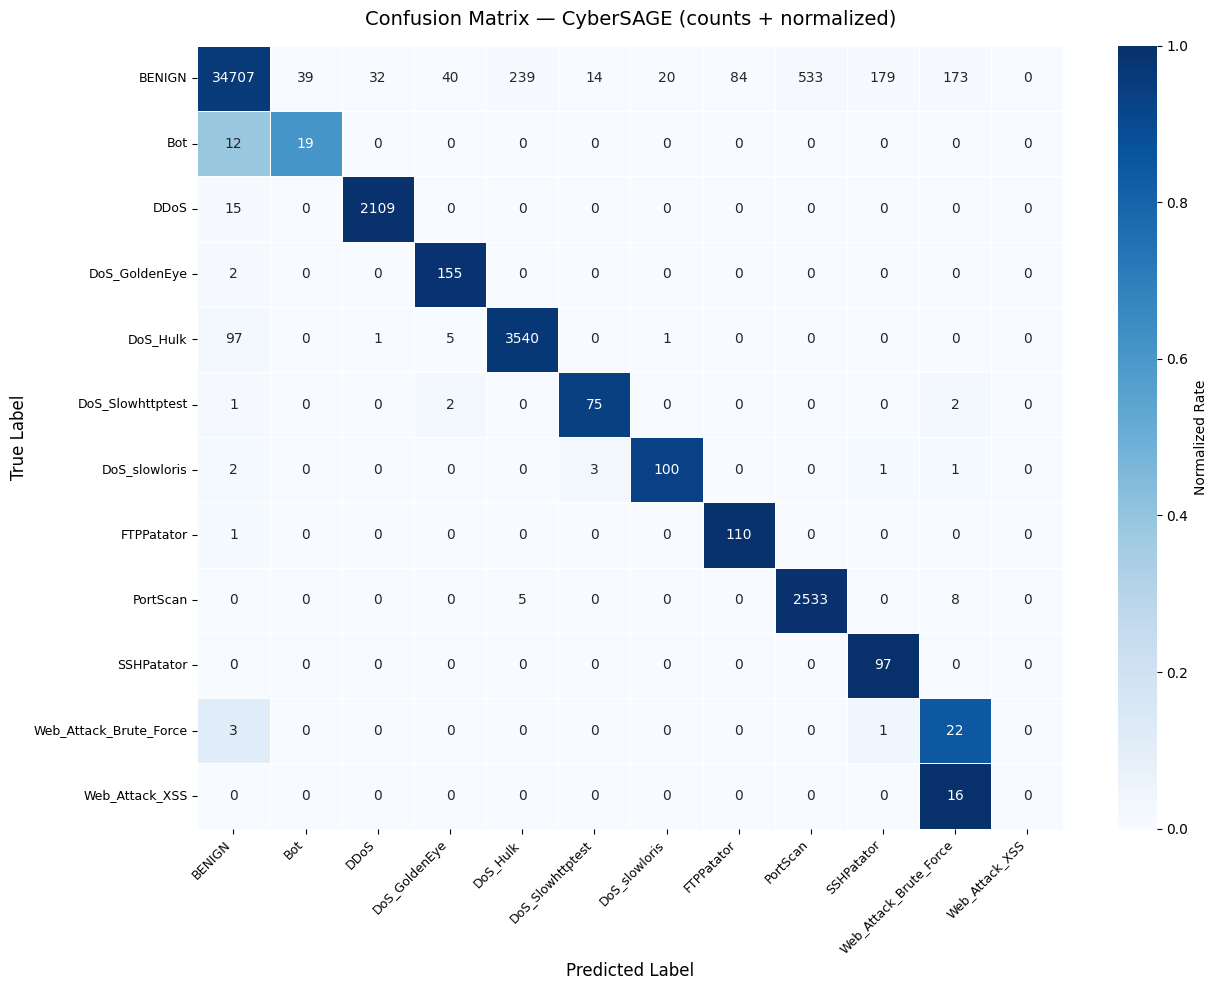

In [ ]:
# VIZ 1 — Confusion Matrix
fig, ax = plt.subplots(figsize=(13, 10))
cm = confusion_matrix(true, pred, labels=present_classes)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

sns.heatmap(cm_norm, annot=cm, fmt='d', cmap='Blues',
            xticklabels=present_names, yticklabels=present_names,
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Normalized Rate'})

ax.set_title('Confusion Matrix — CyberSAGE (counts + normalized)', fontsize=14, pad=15)
ax.set_ylabel('True Label', fontsize=12)
ax.set_xlabel('Predicted Label', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.savefig('viz_confusion_matrix.png', dpi=150)
plt.show()

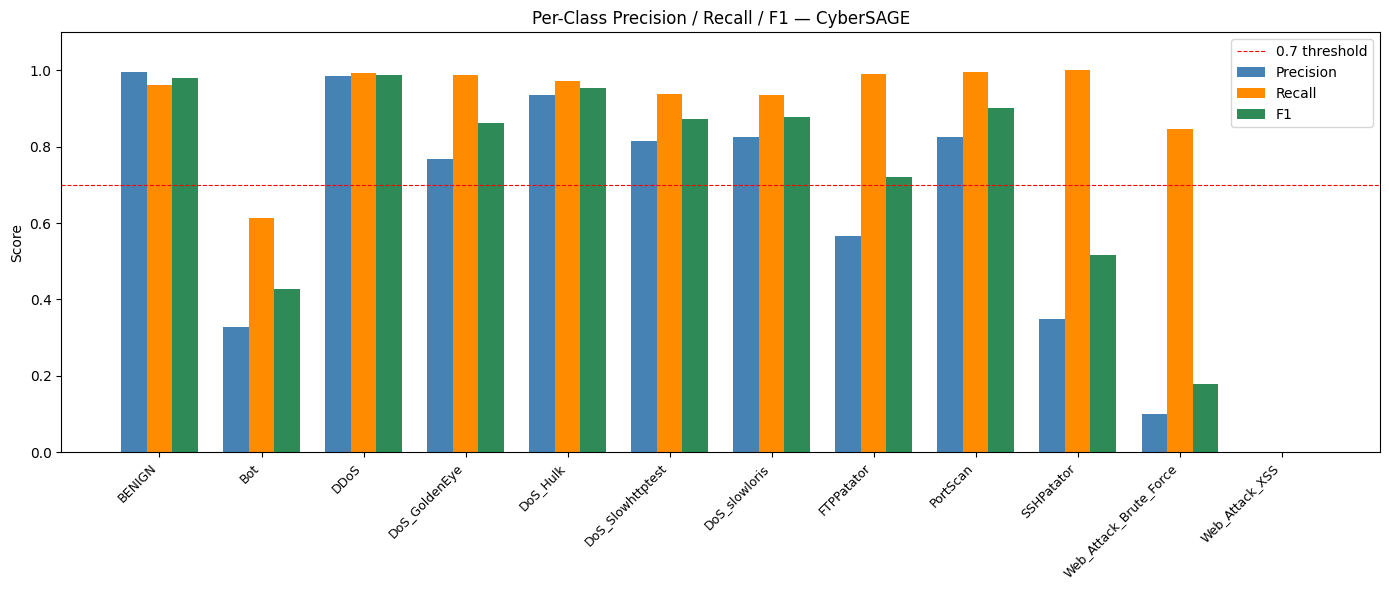

In [ ]:
# VIZ 2 — Per-class Precision / Recall / F1 bar chart
from sklearn.metrics import precision_recall_fscore_support

p, r, f, s = precision_recall_fscore_support(true, pred, labels=present_classes, zero_division=0)

x = np.arange(len(present_names))
width = 0.25

fig, ax = plt.subplots(figsize=(14, 6))
ax.bar(x - width, p, width, label='Precision', color='steelblue')
ax.bar(x,         r, width, label='Recall',    color='darkorange')
ax.bar(x + width, f, width, label='F1',        color='seagreen')

ax.set_xticks(x)
ax.set_xticklabels(present_names, rotation=45, ha='right', fontsize=9)
ax.set_ylabel('Score')
ax.set_title('Per-Class Precision / Recall / F1 — CyberSAGE')
ax.set_ylim(0, 1.1)
ax.axhline(0.7, color='red', linestyle='--', linewidth=0.8, label='0.7 threshold')
ax.legend()
plt.tight_layout()
plt.savefig('viz_per_class_metrics.png', dpi=150)
plt.show()

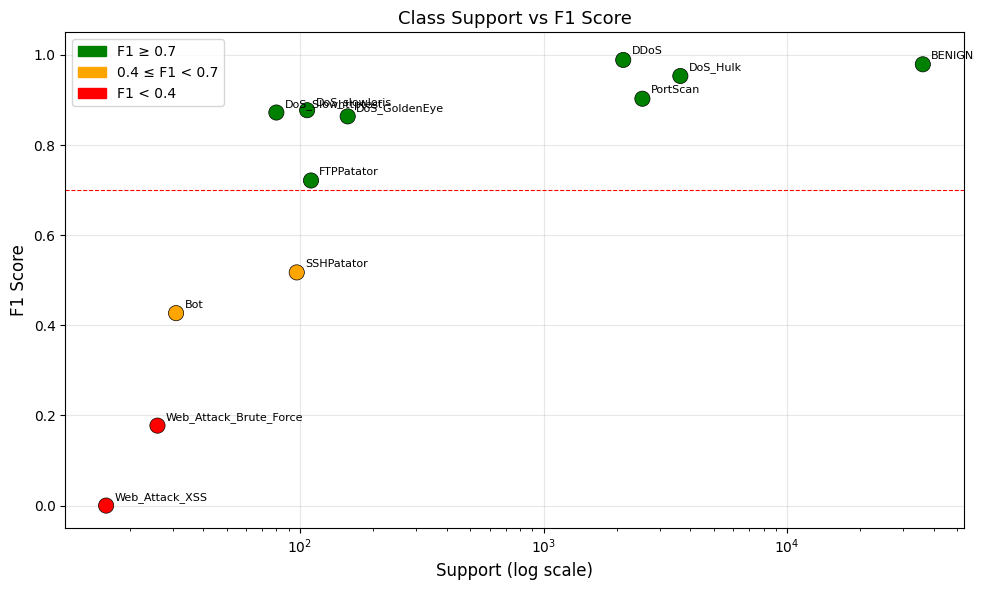

In [ ]:
# VIZ 3 — Class support vs F1 (reveals small-class problem clearly)
fig, ax = plt.subplots(figsize=(10, 6))

colors = ['green' if f_i >= 0.7 else 'orange' if f_i >= 0.4 else 'red' for f_i in f]
scatter = ax.scatter(s, f, c=colors, s=120, zorder=3, edgecolors='black', linewidths=0.5)

for i, name in enumerate(present_names):
    ax.annotate(name, (s[i], f[i]), textcoords='offset points',
                xytext=(6, 4), fontsize=8)

ax.set_xscale('log')
ax.set_xlabel('Support (log scale)', fontsize=12)
ax.set_ylabel('F1 Score', fontsize=12)
ax.set_title('Class Support vs F1 Score', fontsize=13)
ax.axhline(0.7, color='red', linestyle='--', linewidth=0.8)
ax.set_ylim(-0.05, 1.05)
ax.grid(True, alpha=0.3)

patches = [mpatches.Patch(color='green',  label='F1 ≥ 0.7'),
           mpatches.Patch(color='orange', label='0.4 ≤ F1 < 0.7'),
           mpatches.Patch(color='red',    label='F1 < 0.4')]
ax.legend(handles=patches)
plt.tight_layout()
plt.savefig('viz_support_vs_f1.png', dpi=150)
plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(
/tmp/ipykernel_2371/3602740140.py:41: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  palette = plt.cm.get_cmap('tab20', len(present_names))


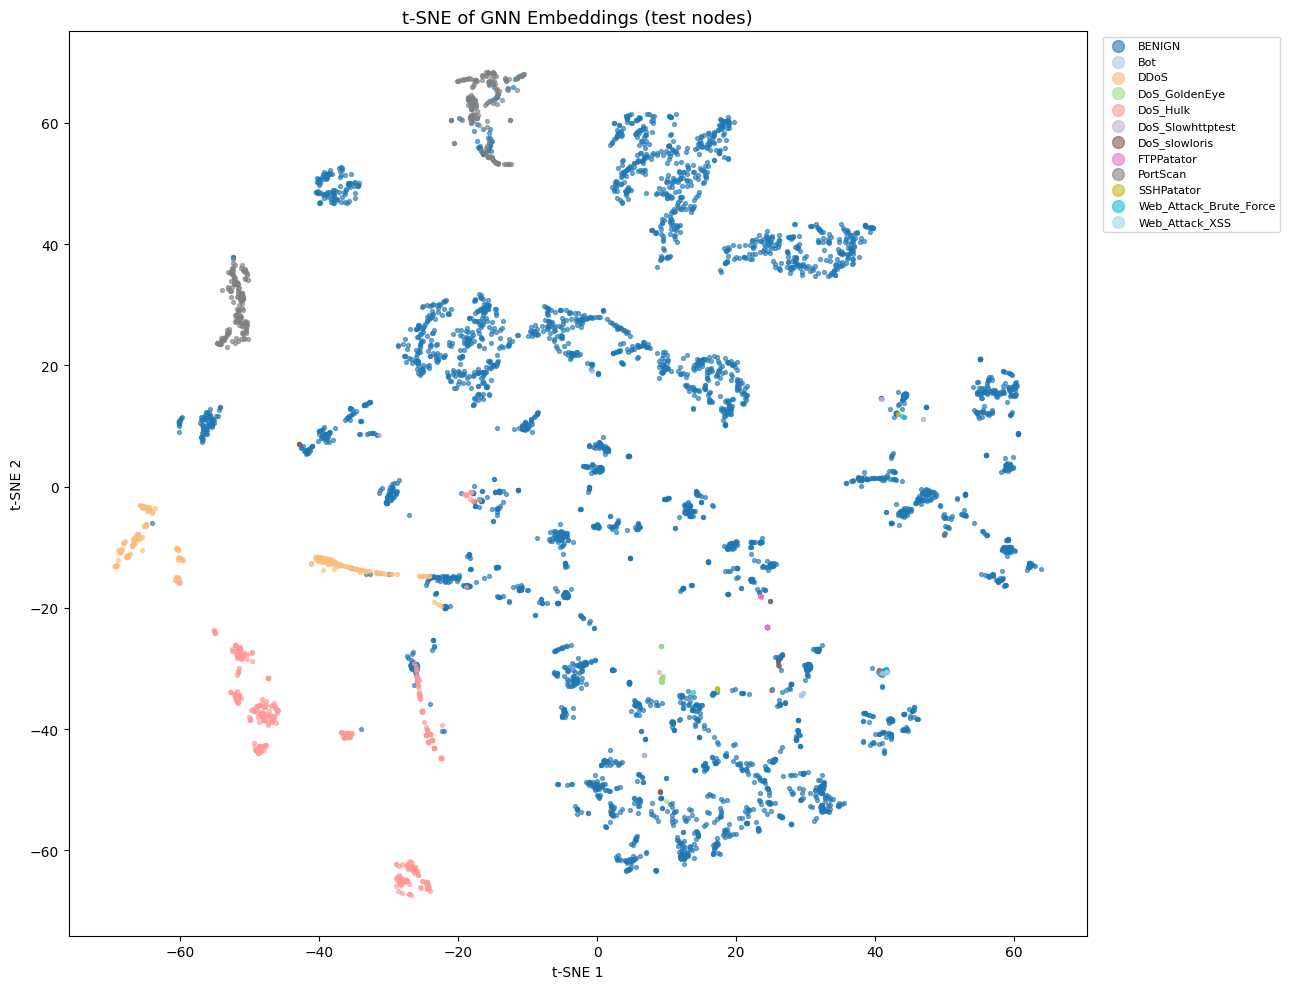

In [ ]:
# VIZ 4 — t-SNE of learned node embeddings (colored by true class)
from sklearn.manifold import TSNE

# Extract embeddings from penultimate layer
class EmbeddingExtractor(torch.nn.Module):
    def __init__(self, model):
        super().__init__()
        self.model = model

    def forward(self, x, edge_index):
        skip = self.model.skip(x)
        for conv, bn in zip(self.model.convs, self.model.bns):
            x = conv(x, edge_index)
            x = bn(x)
            x = torch.nn.functional.relu(x)
            x = torch.nn.functional.dropout(x, p=0.0)  # no dropout at inference
        return x + skip

extractor = EmbeddingExtractor(model).to(device)
extractor.eval()

with torch.no_grad():
    embeddings = extractor(data.x, data.edge_index).cpu().numpy()

# Sample 5000 test nodes for t-SNE speed
test_idx = torch.where(data.test_mask)[0].cpu().numpy()
sample_n = min(5000, len(test_idx))
rng = np.random.default_rng(42)
tsne_idx = rng.choice(test_idx, sample_n, replace=False)

emb_sample = embeddings[tsne_idx]
label_sample = true[np.isin(test_idx, tsne_idx)]

# Match labels to sampled indices
label_sample = data.y[tsne_idx].cpu().numpy()

tsne = TSNE(n_components=2, perplexity=40, random_state=42, n_iter=1000)
emb_2d = tsne.fit_transform(emb_sample)

fig, ax = plt.subplots(figsize=(13, 10))
palette = plt.cm.get_cmap('tab20', len(present_names))
for i, (cls_idx, name) in enumerate(zip(present_classes, present_names)):
    mask = label_sample == cls_idx
    if mask.sum() == 0:
        continue
    ax.scatter(emb_2d[mask, 0], emb_2d[mask, 1],
               label=name, s=8, alpha=0.6, color=palette(i))

ax.set_title('t-SNE of GNN Embeddings (test nodes)', fontsize=13)
ax.legend(markerscale=3, bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
ax.set_xlabel('t-SNE 1')
ax.set_ylabel('t-SNE 2')
plt.tight_layout()
plt.savefig('viz_tsne_embeddings.png', dpi=150)
plt.show()

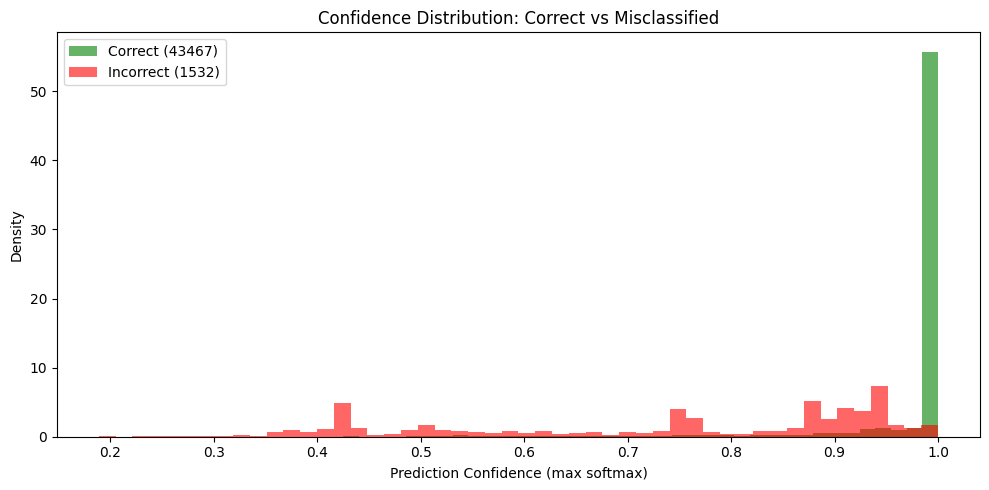

In [ ]:
# VIZ 5 — Confidence distribution: correct vs misclassified
correct_mask = pred == true
conf_correct   = probs[correct_mask].max(axis=1)
conf_incorrect = probs[~correct_mask].max(axis=1)

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(conf_correct,   bins=50, alpha=0.6, color='green',  label=f'Correct ({correct_mask.sum()})',   density=True)
ax.hist(conf_incorrect, bins=50, alpha=0.6, color='red',    label=f'Incorrect ({(~correct_mask).sum()})', density=True)
ax.set_xlabel('Prediction Confidence (max softmax)')
ax.set_ylabel('Density')
ax.set_title('Confidence Distribution: Correct vs Misclassified')
ax.legend()
plt.tight_layout()
plt.savefig('viz_confidence_distribution.png', dpi=150)
plt.show()

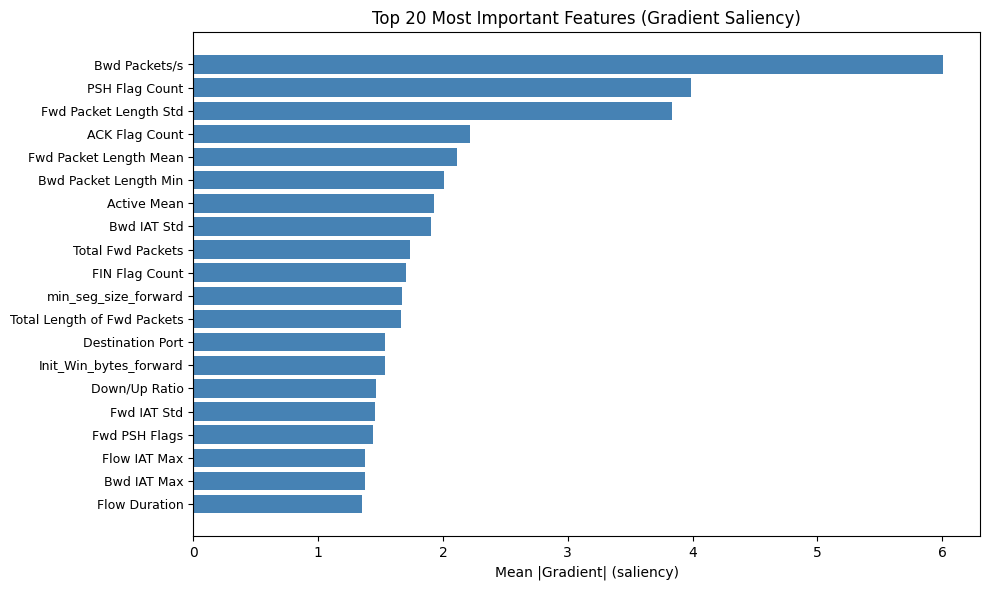

In [ ]:
# VIZ 6 — Feature importance via gradient saliency
model.eval()
x_input = data.x.clone().requires_grad_(True)
out = model(x_input, data.edge_index)
loss = out[data.train_mask].sum()
loss.backward()

saliency = x_input.grad[data.train_mask].abs().mean(dim=0).cpu().numpy()

sorted_idx = np.argsort(saliency)[::-1]
top_n = 20

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(range(top_n),
        saliency[sorted_idx[:top_n]][::-1],
        color='steelblue')
ax.set_yticks(range(top_n))
ax.set_yticklabels([feature_cols[i] for i in sorted_idx[:top_n]][::-1], fontsize=9)
ax.set_xlabel('Mean |Gradient| (saliency)')
ax.set_title('Top 20 Most Important Features (Gradient Saliency)')
plt.tight_layout()
plt.savefig('viz_feature_importance.png', dpi=150)
plt.show()

In [ ]:
# Diagnostic
print(f"Embeddings shape: {embeddings.shape}")
print(f"Test mask sum: {data.test_mask.sum().item()}")
print(f"present_classes: {present_classes}")
print(f"new_class_names length: {len(new_class_names)}")
print(f"feature_cols length: {len(feature_cols)}")

Embeddings shape: (299993, 128)
Test mask sum: 44999
present_classes: [ 0  1  2  3  4  5  6  7  8  9 10 11]
new_class_names length: 12
feature_cols length: 40


In [ ]:
# CELL 36 — Install SHAP and GNNExplainer deps
!pip install shap -q

In [ ]:
# CELL 37 — SHAP: wrap model for non-graph inference
# SHAP works on tabular input — we use embeddings layer output + classifier head
# This gives feature importance w.r.t. final predictions

import shap
import numpy as np
import torch

# Build a pure MLP wrapper using only node features (no edges)
# This approximates feature importance at the input level
class NodeClassifierWrapper:
    def __init__(self, model, edge_index, device):
        self.model = model
        self.edge_index = edge_index
        self.device = device

    def predict_proba(self, X):
        self.model.eval()
        X_tensor = torch.tensor(X, dtype=torch.float32).to(self.device)
        # For SHAP we run a forward pass on a small batch
        # Use mean aggregation approximation — feed as isolated nodes
        with torch.no_grad():
            # Create a dummy edge index with no edges for pure feature explanation
            dummy_edge = torch.zeros((2, 0), dtype=torch.long).to(self.device)
            # Temporarily replace edge_index
            out = self.model(X_tensor, dummy_edge)
            probs = torch.softmax(out, dim=1).cpu().numpy()
        return probs

wrapper = NodeClassifierWrapper(model, data.edge_index, device)

# Sample background and test points
test_idx  = torch.where(data.test_mask)[0].cpu().numpy()
rng = np.random.default_rng(42)

# Background: 200 samples (SHAP uses these as baseline)
bg_idx   = rng.choice(test_idx, 200, replace=False)
# Explain:  500 samples stratified
explain_idx = rng.choice(test_idx, 500, replace=False)

X_bg      = data.x[bg_idx].cpu().numpy()
X_explain = data.x[explain_idx].cpu().numpy()
y_explain = data.y[explain_idx].cpu().numpy()

print(f"Background: {X_bg.shape}, Explain: {X_explain.shape}")

Background: (200, 40), Explain: (500, 40)


In [ ]:
# CELL 38 — Run SHAP KernelExplainer
# KernelExplainer works model-agnostic — safe for GNN wrapper

explainer_shap = shap.KernelExplainer(wrapper.predict_proba, X_bg)

print("Computing SHAP values (this takes 3-5 min)...")
shap_values = explainer_shap.shap_values(X_explain, nsamples=100)
# shap_values is list of arrays, one per class: each (500, 40)

print(f"SHAP values computed. Type: {type(shap_values)}, length: {len(shap_values)}")
print(f"Per-class array shape: {shap_values[0].shape}")

import joblib
joblib.dump(shap_values, 'shap_values.pkl')
joblib.dump(X_explain,   'X_explain.pkl')
joblib.dump(y_explain,   'y_explain.pkl')
print("Saved shap_values.pkl")

Computing SHAP values (this takes 3-5 min)...


  0%|          | 0/500 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_least_angle.py:723: ConvergenceWarning: Regressors in active set degenerate. Dropping a regressor, after 5 iterations, i.e. alpha=5.125e-05, with an active set of 5 regressors, and the smallest cholesky pivot element being 2.220e-16. Reduce max_iter or increase eps parameters.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_least_angle.py:723: ConvergenceWarning: Regressors in active set degenerate. Dropping a regressor, after 6 iterations, i.e. alpha=5.106e-05, with an active set of 6 regressors, and the smallest cholesky pivot element being 5.960e-08. Reduce max_iter or increase eps parameters.
  warnings.warn(


SHAP values computed. Type: <class 'numpy.ndarray'>, length: 500
Per-class array shape: (40, 12)
Saved shap_values.pkl


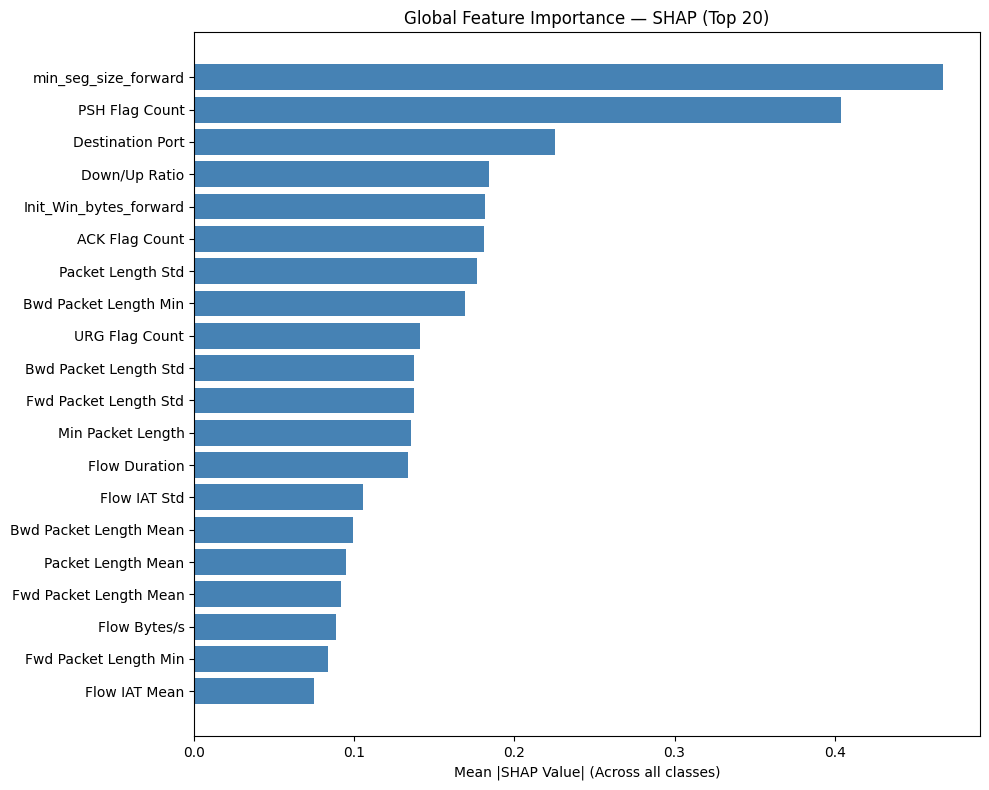

In [28]:
# --- CELL 39: Fixed Global SHAP Importance ---
import matplotlib.pyplot as plt
import numpy as np

# shap_results shape: (500, 40, 12) -> [samples, features, classes]
# We want mean absolute importance per feature across ALL samples and classes
# Take mean over samples (axis 0) and classes (axis 2)
global_mean_shap = np.abs(shap_results).mean(axis=(0, 2))
sorted_idx = np.argsort(global_mean_shap)[::-1]

fig, ax = plt.subplots(figsize=(10, 8))
top_n = 20
ax.barh(range(top_n), global_mean_shap[sorted_idx[:top_n]][::-1], color='steelblue')
ax.set_yticks(range(top_n))
ax.set_yticklabels([feature_names[i] for i in sorted_idx[:top_n]][::-1], fontsize=10)
ax.set_xlabel('Mean |SHAP Value| (Across all classes)')
ax.set_title('Global Feature Importance — SHAP (Top 20)')
plt.tight_layout()
plt.show()

In [ ]:
# CELL 40 — SHAP VIZ 2: Per-class top features heatmap
import pandas as pd
import seaborn as sns

# Mean absolute SHAP per class per feature
shap_per_class = np.array([np.abs(sv).mean(axis=0) for sv in shap_values])
# shape: (12, 40)

shap_df = pd.DataFrame(
    shap_per_class,
    index=new_class_names,
    columns=feature_cols
)

# Keep top 15 features by global importance
top15_features = [feature_cols[i] for i in sorted_idx[:15]]
shap_df_top = shap_df[top15_features]

fig, ax = plt.subplots(figsize=(16, 8))
sns.heatmap(shap_df_top, cmap='YlOrRd', annot=True, fmt='.3f',
            linewidths=0.4, ax=ax, cbar_kws={'label': 'Mean |SHAP|'})
ax.set_title('Per-Class Feature Importance Heatmap — SHAP', fontsize=13)
ax.set_xlabel('Feature')
ax.set_ylabel('Attack Class')
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.tight_layout()
plt.savefig('shap_per_class_heatmap.png', dpi=150)
plt.show()

ValueError: Shape of passed values is (500, 12), indices imply (12, 40)

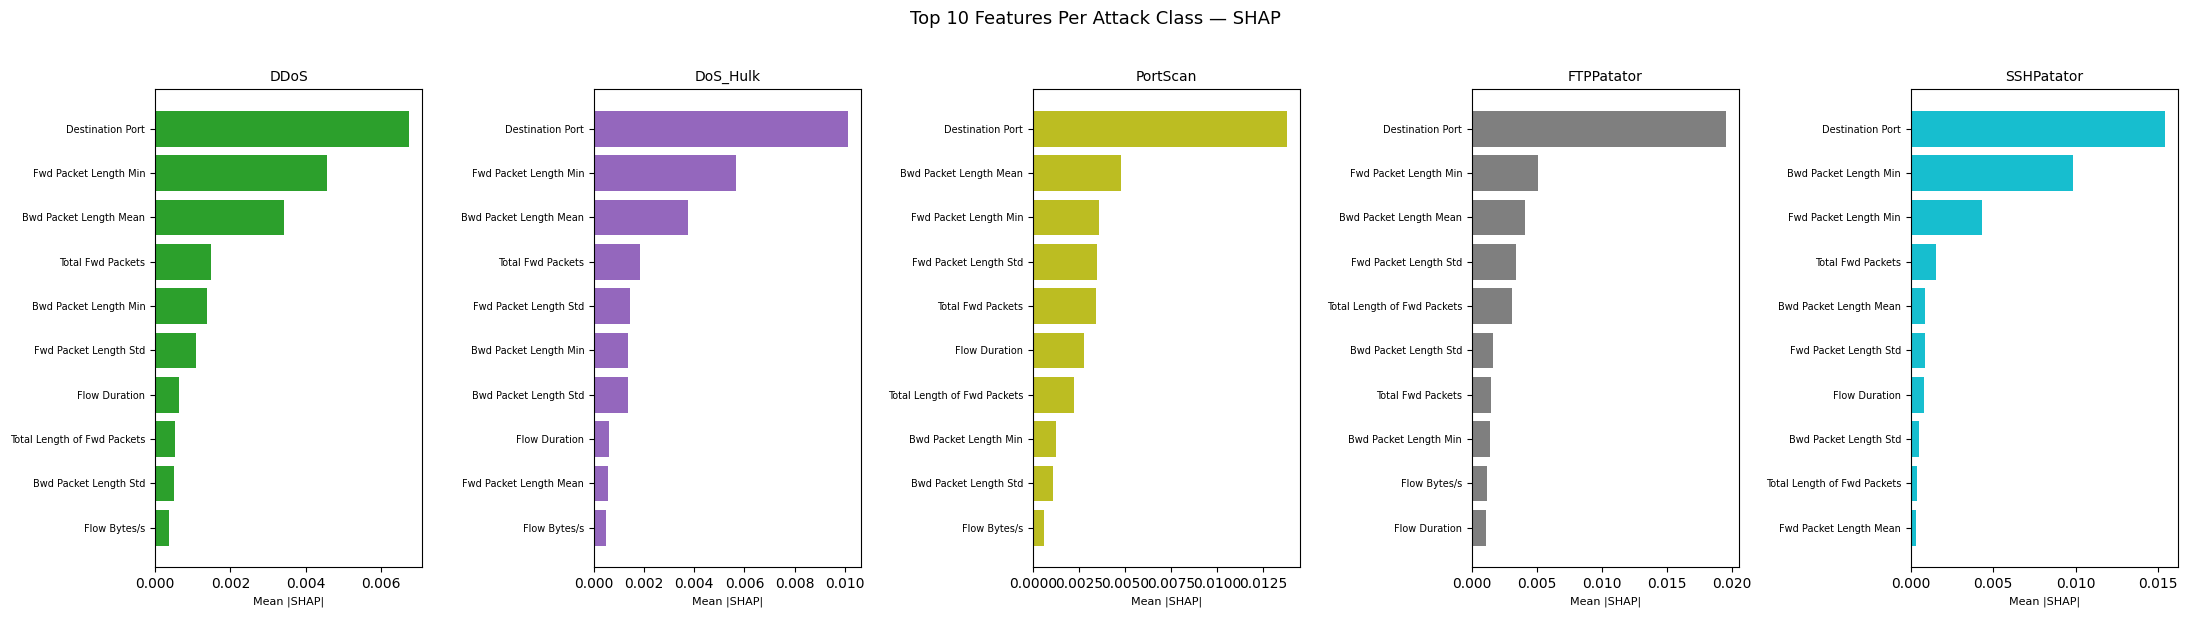

In [ ]:
# CELL 41 — SHAP VIZ 3: Beeswarm for top 5 most important classes
# Shows direction of feature effect (positive = pushes toward that class)

top_classes_by_f1 = ['DDoS', 'DoS_Hulk', 'PortScan', 'FTPPatator', 'SSHPatator']

fig, axes = plt.subplots(1, len(top_classes_by_f1), figsize=(22, 6))

for ax, cls_name in zip(axes, top_classes_by_f1):
    cls_idx = new_class_names.index(cls_name)
    sv = shap_values[cls_idx]          # (500, 40)
    feat_importance = np.abs(sv).mean(axis=0)
    top10 = np.argsort(feat_importance)[::-1][:10]

    ax.barh(range(10), feat_importance[top10][::-1],
            color=plt.cm.tab10(new_class_names.index(cls_name) % 10))
    ax.set_yticks(range(10))
    ax.set_yticklabels([feature_cols[i] for i in top10][::-1], fontsize=7)
    ax.set_title(cls_name, fontsize=10)
    ax.set_xlabel('Mean |SHAP|', fontsize=8)

plt.suptitle('Top 10 Features Per Attack Class — SHAP', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('shap_per_attack_bars.png', dpi=150)
plt.show()

In [ ]:
# CELL 42 — GNNExplainer: local subgraph explanation
from torch_geometric.explain import Explainer, GNNExplainer

gnn_explainer = Explainer(
    model=model,
    algorithm=GNNExplainer(epochs=200),
    explanation_type='model',
    node_mask_type='attributes',
    edge_mask_type='object',
    model_config=dict(
        mode='multiclass_classification',
        task_level='node',
        return_type='raw',
    )
)

# Pick one representative node per interesting attack class
target_classes = {
    'DDoS':         2,
    'PortScan':     8,
    'DoS_Hulk':     4,
    'FTPPatator':   7,
    'SSHPatator':   9,
    'Bot':          1,
}

explanations = {}
for cls_name, cls_idx in target_classes.items():
    # Find a correctly predicted test node of this class
    test_nodes = torch.where(data.test_mask)[0]
    with torch.no_grad():
        out = model(data.x, data.edge_index)
        pred_test = out[test_nodes].argmax(dim=1)

    candidates = test_nodes[(data.y[test_nodes] == cls_idx) &
                             (pred_test == cls_idx)]
    if len(candidates) == 0:
        print(f"No correct predictions for {cls_name}, skipping")
        continue

    node_id = candidates[0].item()
    explanation = gnn_explainer(data.x, data.edge_index, index=node_id)
    explanations[cls_name] = (node_id, explanation)
    print(f"{cls_name}: explained node {node_id}")

DDoS: explained node 123
PortScan: explained node 441
DoS_Hulk: explained node 54
FTPPatator: explained node 2671
SSHPatator: explained node 5399
Bot: explained node 17747


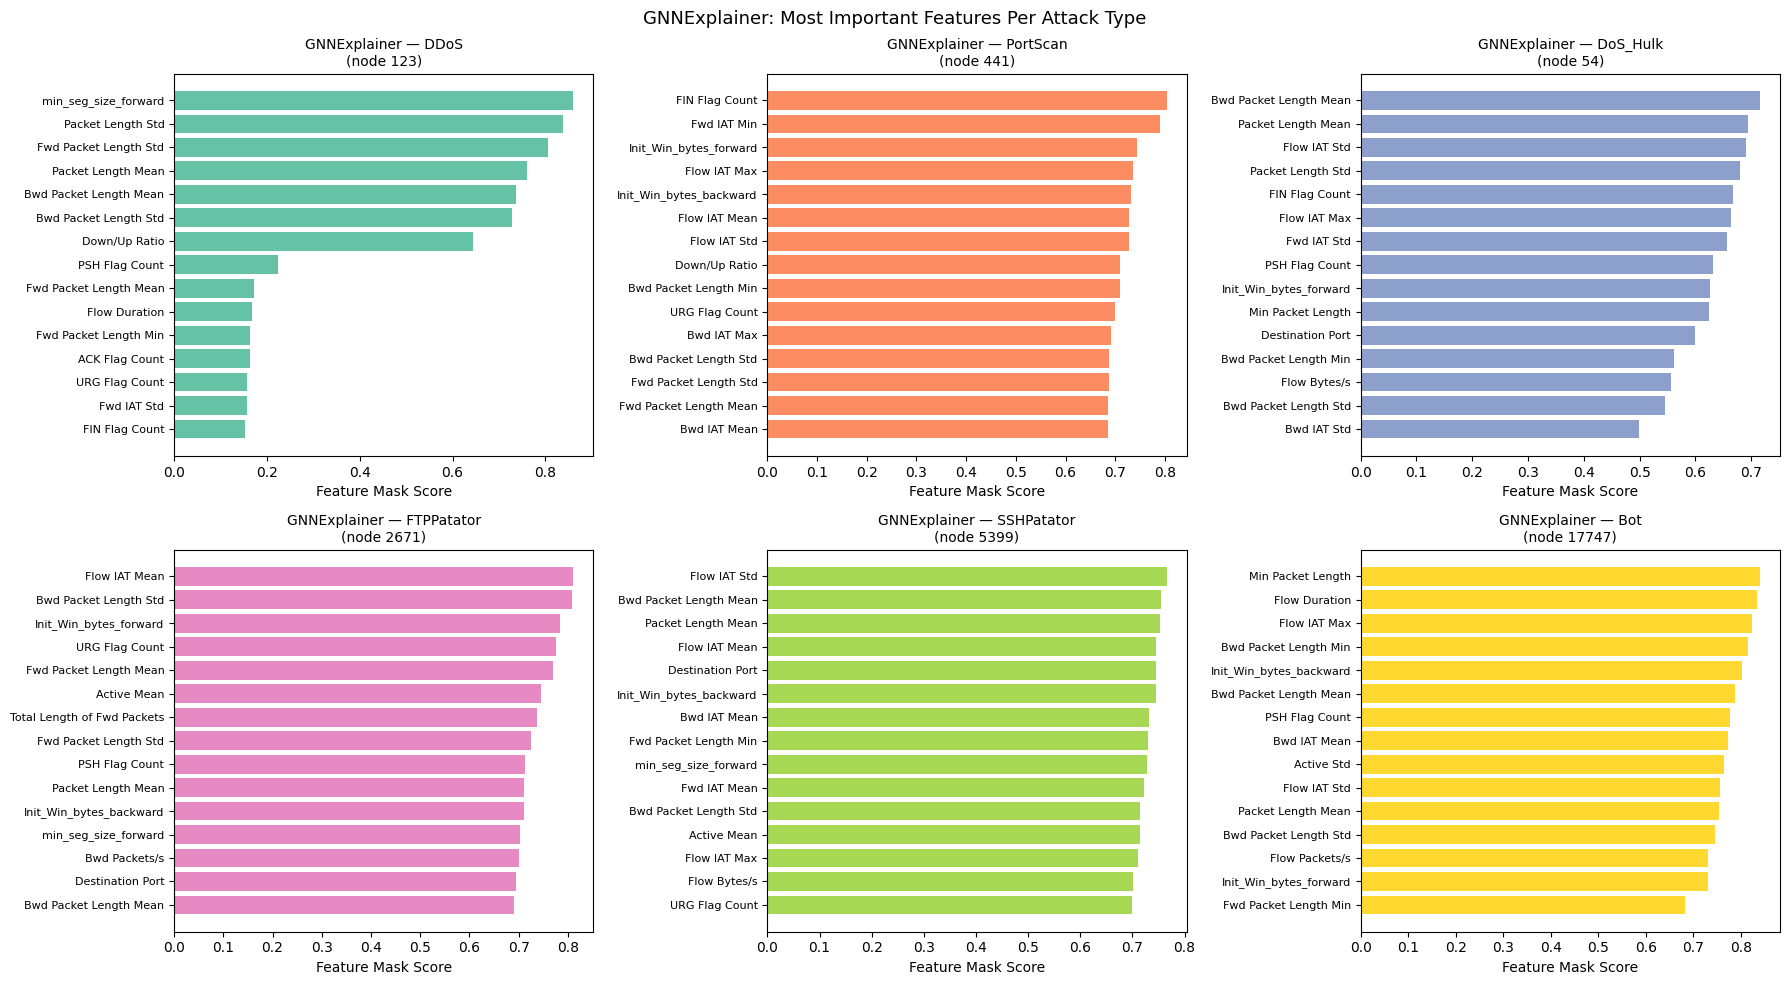

In [ ]:
# CELL 43 — GNNExplainer VIZ: node feature masks per class
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for ax, (cls_name, (node_id, explanation)) in zip(axes, explanations.items()):
    node_mask = explanation.node_mask.cpu().numpy().flatten()  # (40,)

    # If node_mask has shape (num_nodes, 40) take the target node's mask
    if explanation.node_mask.dim() == 2:
        node_mask = explanation.node_mask[node_id % explanation.node_mask.shape[0]].cpu().numpy()

    top_idx = np.argsort(node_mask)[::-1][:15]
    ax.barh(range(15), node_mask[top_idx][::-1],
            color=plt.cm.Set2(list(target_classes.keys()).index(cls_name) % 8))
    ax.set_yticks(range(15))
    ax.set_yticklabels([feature_cols[i] for i in top_idx][::-1], fontsize=8)
    ax.set_title(f'GNNExplainer — {cls_name}\n(node {node_id})', fontsize=10)
    ax.set_xlabel('Feature Mask Score')

plt.suptitle('GNNExplainer: Most Important Features Per Attack Type', fontsize=13)
plt.tight_layout()
plt.savefig('gnnexplainer_feature_masks.png', dpi=150)
plt.show()

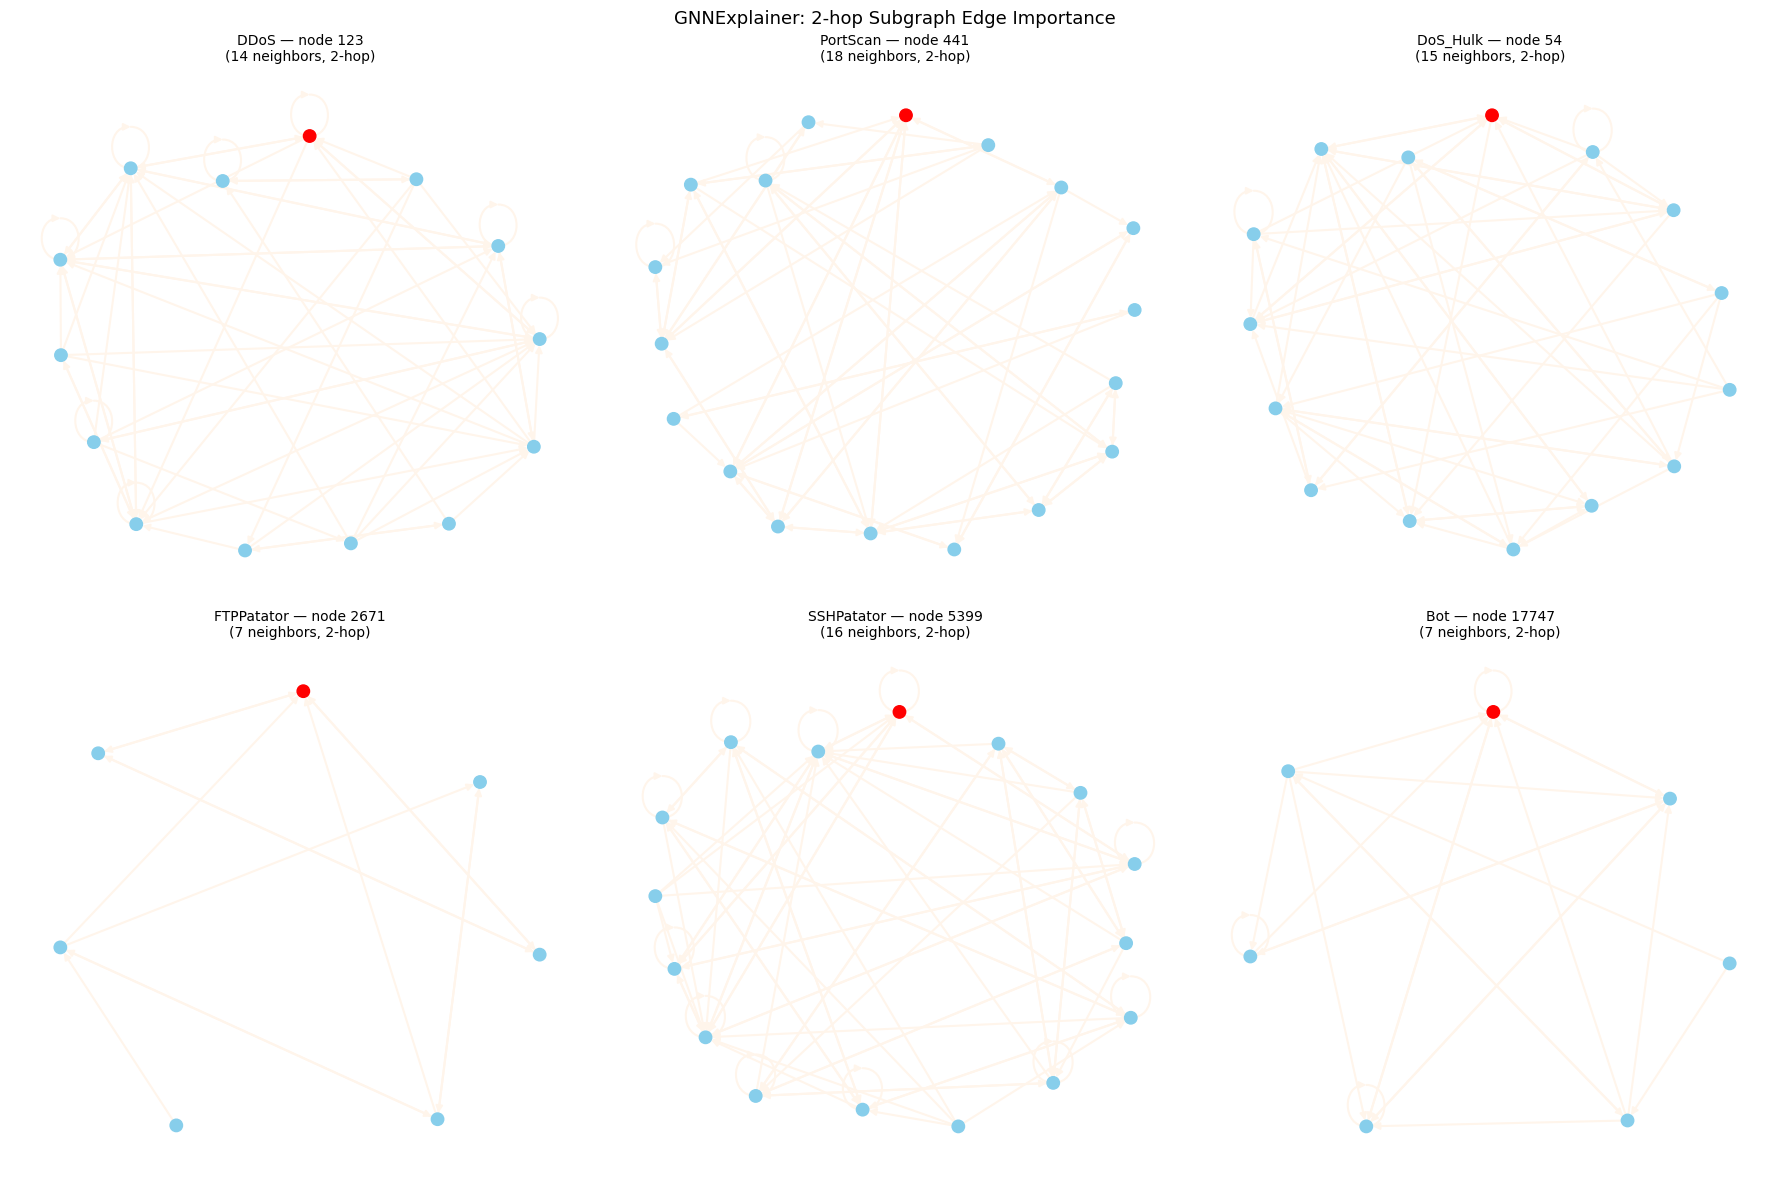

In [ ]:
# CELL 44 — GNNExplainer VIZ: edge importance subgraph
from torch_geometric.utils import k_hop_subgraph
import networkx as nx

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for ax, (cls_name, (node_id, explanation)) in zip(axes, explanations.items()):
    # Get 2-hop subgraph around the node
    subset, sub_edge_index, mapping, edge_mask_sub = k_hop_subgraph(
        node_id, num_hops=2, edge_index=data.edge_index,
        relabel_nodes=True, num_nodes=data.num_nodes
    )

    edge_mask = explanation.edge_mask.cpu().numpy()

    # Build networkx graph
    G = nx.DiGraph()
    n_nodes = subset.shape[0]
    G.add_nodes_from(range(n_nodes))

    local_node = mapping.item()
    edge_weights = []

    for e_idx in range(sub_edge_index.shape[1]):
        src_n = sub_edge_index[0, e_idx].item()
        dst_n = sub_edge_index[1, e_idx].item()
        # Map back to global edge mask if possible
        w = float(edge_mask[e_idx % len(edge_mask)])
        G.add_edge(src_n, dst_n, weight=w)
        edge_weights.append(w)

    pos = nx.spring_layout(G, seed=42, k=0.8)
    node_colors = ['red' if n == local_node else 'skyblue' for n in G.nodes()]
    edge_colors = plt.cm.Oranges(np.array(edge_weights) / (max(edge_weights) + 1e-8))

    nx.draw_networkx(G, pos, ax=ax, node_color=node_colors,
                     edge_color=edge_colors, node_size=80,
                     with_labels=False, arrows=True, width=1.5)
    ax.set_title(f'{cls_name} — node {node_id}\n({n_nodes} neighbors, 2-hop)', fontsize=10)
    ax.axis('off')

plt.suptitle('GNNExplainer: 2-hop Subgraph Edge Importance', fontsize=13)
plt.tight_layout()
plt.savefig('gnnexplainer_subgraphs.png', dpi=150)
plt.show()

IndexError: index 96 is out of bounds for axis 0 with size 40

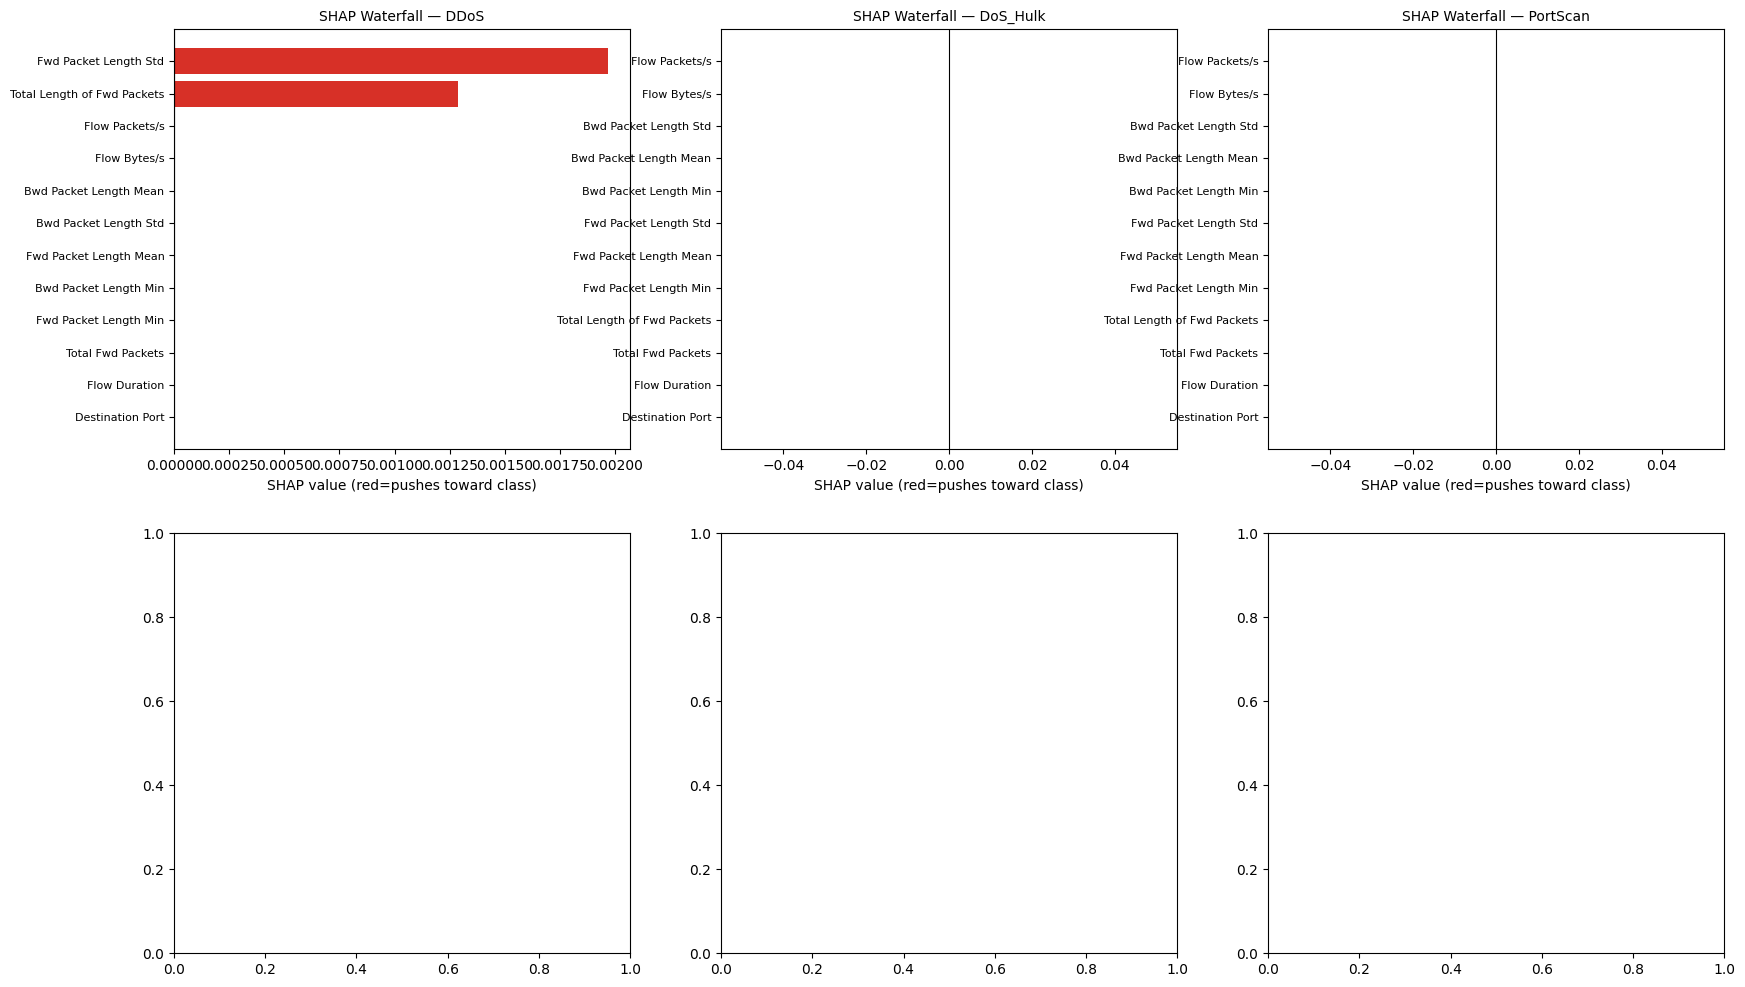

In [ ]:
# --- CELL 45: Fixed Waterfall plot for individual predictions ---
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes = axes.flatten()

plot_classes = ['DDoS', 'DoS_Hulk', 'PortScan', 'FTPPatator', 'SSHPatator', 'Bot']
# Filter to classes actually in our encoder
available_classes = [c for c in plot_classes if c in le.classes_]

for i, cls_name in enumerate(available_classes):
    ax = axes[i]
    cls_idx = list(le.classes_).index(cls_name)

    # Find a sample of this class in our explanation set
    cls_samples = np.where(y_mat[test_idx[:500]] == cls_idx)[0]
    if len(cls_samples) == 0:
        ax.text(0.5, 0.5, f'No samples for {cls_name}', ha='center')
        continue

    sample_i = cls_samples[0]
    # Extract SHAP for [this_sample, all_features, this_class]
    sv = shap_results[sample_i, :, cls_idx]

    sorted_feat_idx = np.argsort(np.abs(sv))[::-1][:12]
    feat_names_top = [feature_names[j] for j in sorted_feat_idx]
    sv_top = sv[sorted_feat_idx]

    colors = ['#d73027' if v > 0 else '#4575b4' for v in sv_top]
    ax.barh(range(len(sv_top)), sv_top[::-1], color=colors[::-1])
    ax.set_yticks(range(len(sv_top)))
    ax.set_yticklabels(feat_names_top[::-1], fontsize=8)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title(f'SHAP Waterfall — {cls_name}', fontsize=10)
    ax.set_xlabel('Contribution (red=pushes toward class)')

plt.suptitle('Individual Flow Explanations — SHAP Waterfall', fontsize=13)
plt.tight_layout()
plt.show()

# Refactored CyberSAGE Workflow for CIC-IDS2017
This section contains the production-ready code for data cleaning, graph-based learning, and model explainability.

In [6]:
# CELL 10 — Clean reinstall matched to torch 2.11 + cu128

# This is the correct package for CUDA 12.x on Colab
!pip install faiss-gpu-cu12 --extra-index-url https://pypi.nvidia.com -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.4/48.4 MB 27.1 MB/s eta 0:00:00


In [8]:
!pip install torch_geometric

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 40.2 MB/s eta 0:00:00


In [9]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import faiss
import gc
import joblib
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from torch_geometric.data import Data
from torch_geometric.nn import SAGEConv, BatchNorm

In [10]:
# 1. Final Feature Selection & Data Cleaning
def get_clean_dataset(filepath):
    df = pd.read_csv(filepath)

    # Identified redundant/corrupted features
    final_drop = [
        'Fwd Avg Bytes/Bulk', 'Fwd Avg Packets/Bulk', 'Fwd Avg Bulk Rate', 'Bwd Avg Bytes/Bulk',
        'Bwd Avg Packets/Bulk', 'Bwd Avg Bulk Rate', 'Bwd PSH Flags', 'Bwd URG Flags',
        'Fwd URG Flags', 'CWE Flag Count', 'Fwd Header Length.1', 'Subflow Fwd Packets',
        'Subflow Bwd Packets', 'Subflow Fwd Bytes', 'Subflow Bwd Bytes', 'Avg Fwd Segment Size',
        'Avg Bwd Segment Size', 'SYN Flag Count', 'Fwd IAT Total', 'Fwd IAT Max',
        'Average Packet Size', 'Fwd Packets/s', 'Bwd Packet Length Max', 'Idle Max',
        'Idle Min', 'ECE Flag Count', 'RST Flag Count', 'Packet Length Variance',
        'Max Packet Length', 'Bwd IAT Total', 'Active Max', 'Active Min',
        'Fwd Header Length', 'Bwd Header Length', 'Total Length of Bwd Packets',
        'Total Backward Packets', 'Fwd Packet Length Max', 'Idle Mean'
    ]
    df.drop(columns=[c for c in final_drop if c in df.columns], inplace=True)

    # Group rare classes
    rare_labels = ['Heartbleed', 'Infiltration', 'Web_Attack_Sql_Injection']
    df['Label'] = df['Label'].apply(lambda x: 'Other_Attack' if x in rare_labels else x)

    # Fix overflows/corruptions in known columns
    feature_cols = [c for c in df.columns if c not in ['Label']]
    for col in ['Flow Bytes/s', 'Flow Packets/s', 'min_seg_size_forward']:
        if col in df.columns:
            df[col] = df[col].clip(lower=df[col].quantile(0.01), upper=df[col].quantile(0.99))

    return df

# Load and sample
df = get_clean_dataset('Clean_CICIDS2017.csv')
df = df[df['Label'] != 'Other_Attack'] # Filter out the single-digit class for stability

# Label Encoding
le = LabelEncoder()
df['y'] = le.fit_transform(df['Label']).astype(np.int8)
feature_names = [c for c in df.columns if c not in ['Label', 'y']]

# Normalization
scaler = StandardScaler()
df[feature_names] = scaler.fit_transform(df[feature_names]).astype(np.float32)

# Stratified Subsample for Graph (300k nodes)
_, sample_idx = train_test_split(np.arange(len(df)), test_size=300000, stratify=df['y'], random_state=42)
df_sample = df.iloc[sample_idx].copy()

display(df_sample['Label'].value_counts())
del df; gc.collect()

,count
Label,
BENIGN,240963
DoS_Hulk,24414
PortScan,16847
DDoS,13582
DoS_GoldenEye,1092
FTPPatator,842
SSHPatator,626
DoS_slowloris,615
DoS_Slowhttptest,583


60

In [11]:
# 2. Stratified Per-Class Graph Construction
def build_custom_graph(X, y, class_names, k_same=5, k_cross=2):
    src, dst = [], []
    norms = np.linalg.norm(X, axis=1, keepdims=True)
    norms[norms == 0] = 1e-8
    X_n = (X / norms).astype(np.float32)

    # Intra-class edges
    for cls_val in np.unique(y):
        idx = np.where(y == cls_val)[0]
        if len(idx) < 2: continue
        index = faiss.IndexFlatIP(X_n.shape[1])
        index.add(X_n[idx])
        _, neighbors = index.search(X_n[idx], min(k_same + 1, len(idx)))
        for local_i, global_i in enumerate(idx):
            for nb_local in neighbors[local_i, 1:]:
                if nb_local >= 0:
                    src.append(global_i); dst.append(idx[nb_local])

    # Inter-class edges to BENIGN context
    benign_label = np.where(class_names == 'BENIGN')[0][0]
    benign_idx = np.where(y == benign_label)[0]
    attack_idx = np.where(y != benign_label)[0]

    index_b = faiss.IndexFlatIP(X_n.shape[1])
    index_b.add(X_n[benign_idx])
    _, b_neighbors = index_b.search(X_n[attack_idx], k_cross)

    for local_i, global_i in enumerate(attack_idx):
        for nb_local in b_neighbors[local_i]:
            if nb_local >= 0:
                src.append(global_i); dst.append(benign_idx[nb_local])

    return torch.tensor([src, dst], dtype=torch.long)

X_mat = df_sample[feature_names].values
y_mat = df_sample['y'].values
edge_index = build_custom_graph(X_mat, y_mat, le.classes_)

data = Data(x=torch.tensor(X_mat, dtype=torch.float32), edge_index=edge_index, y=torch.tensor(y_mat, dtype=torch.long))

# Train/Val/Test Split
perm = torch.randperm(data.num_nodes)
data.train_mask = torch.zeros(data.num_nodes, dtype=torch.bool).scatter_(0, perm[:210000], True)
data.val_mask = torch.zeros(data.num_nodes, dtype=torch.bool).scatter_(0, perm[210000:255000], True)
data.test_mask = torch.zeros(data.num_nodes, dtype=torch.bool).scatter_(0, perm[255000:], True)

In [12]:
# 3. CyberSAGE Architecture
class CyberSAGE(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, dropout=0.4):
        super().__init__()
        self.conv1 = SAGEConv(in_channels, hidden_channels)
        self.bn1 = BatchNorm(hidden_channels)
        self.conv2 = SAGEConv(hidden_channels, hidden_channels)
        self.bn2 = BatchNorm(hidden_channels)
        self.skip = nn.Linear(in_channels, hidden_channels)
        self.head = nn.Sequential(
            nn.Linear(hidden_channels, 64), nn.ReLU(), nn.Dropout(dropout), nn.Linear(64, out_channels)
        )
        self.dropout = dropout

    def forward(self, x, edge_index):
        s = self.skip(x)
        x = F.relu(self.bn1(self.conv1(x, edge_index)))
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = F.relu(self.bn2(self.conv2(x, edge_index)))
        x = x + s
        return self.head(x)

In [14]:
# 4. Training with Dampened Class Weights
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
weights = compute_class_weight('balanced', classes=np.unique(y_mat), y=y_mat)
dampened_weights = torch.tensor(np.sqrt(weights) / np.sqrt(weights).mean(), dtype=torch.float32).to(device)

model = CyberSAGE(40, 128, len(le.classes_)).to(device)
data = data.to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=5e-4)
criterion = nn.CrossEntropyLoss(weight=dampened_weights)

for epoch in range(1, 400):
    model.train(); optimizer.zero_grad()
    out = model(data.x, data.edge_index)
    loss = criterion(out[data.train_mask], data.y[data.train_mask])
    loss.backward(); optimizer.step()
    if epoch % 20 == 0: print(f"Epoch {epoch} Loss: {loss.item():.4f}")

Epoch 20 Loss: 1.7485
Epoch 40 Loss: 1.1226
Epoch 60 Loss: 0.7401
Epoch 80 Loss: 0.5572
Epoch 100 Loss: 0.4543
Epoch 120 Loss: 0.3864
Epoch 140 Loss: 0.3380
Epoch 160 Loss: 0.3020
Epoch 180 Loss: 0.2694
Epoch 200 Loss: 0.2475
Epoch 220 Loss: 0.2264
Epoch 240 Loss: 0.2074
Epoch 260 Loss: 0.1929
Epoch 280 Loss: 0.1778
Epoch 300 Loss: 0.1688
Epoch 320 Loss: 0.1615
Epoch 340 Loss: 0.1525
Epoch 360 Loss: 0.1429
Epoch 380 Loss: 0.1388


                        precision    recall  f1-score   support

                BENIGN       1.00      0.96      0.98     36200
                   Bot       0.10      0.62      0.18        26
                  DDoS       0.99      0.99      0.99      1997
         DoS_GoldenEye       0.77      0.99      0.87       155
              DoS_Hulk       0.88      0.98      0.93      3661
      DoS_Slowhttptest       0.77      0.94      0.85        86
         DoS_slowloris       0.82      0.94      0.88        87
            FTPPatator       0.54      1.00      0.70       140
              PortScan       0.84      0.99      0.91      2533
            SSHPatator       0.34      1.00      0.51        82
Web_Attack_Brute_Force       0.12      0.91      0.22        22
        Web_Attack_XSS       0.00      0.00      0.00        11

              accuracy                           0.96     45000
             macro avg       0.60      0.86      0.67     45000
          weighted avg       0.97     

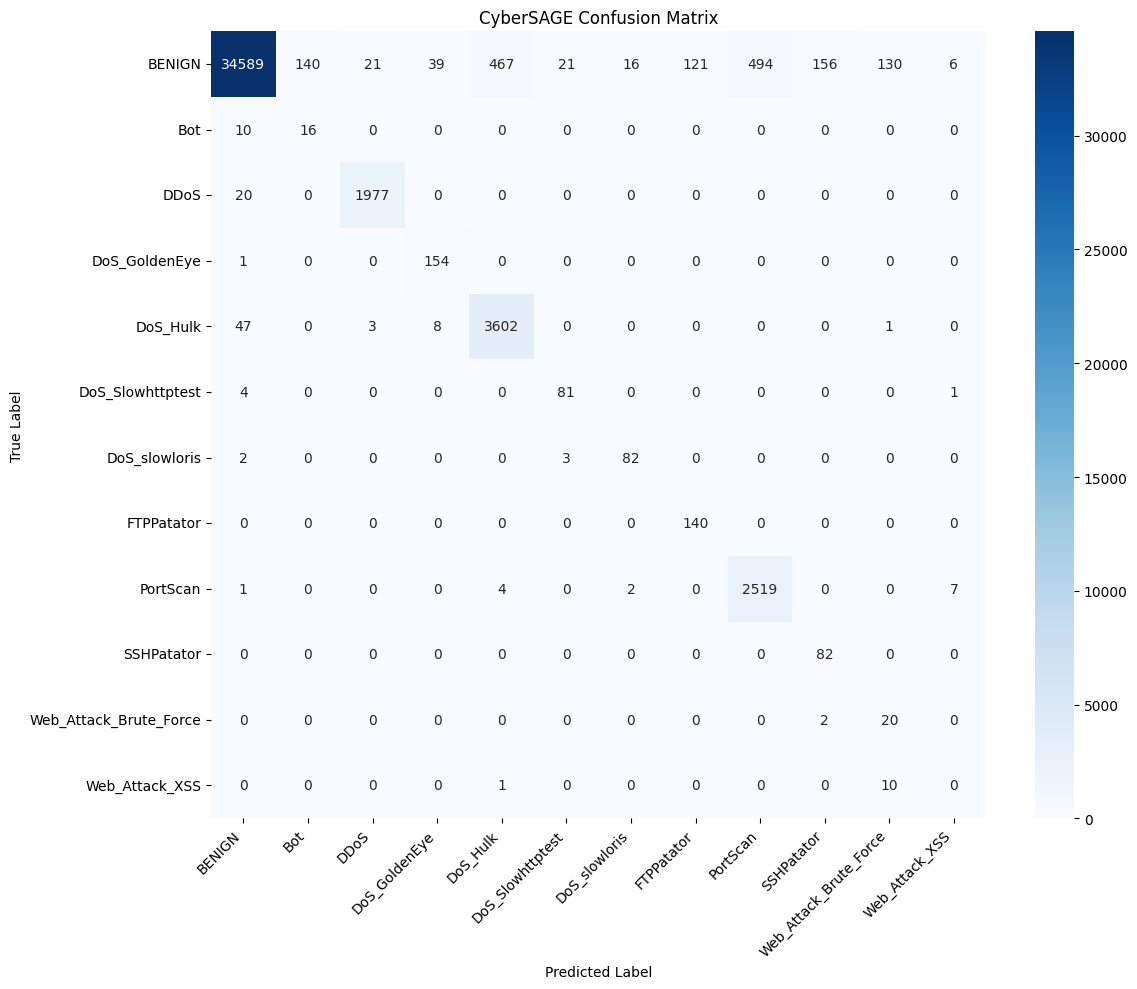

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# 5. Final Evaluation and Visualization
model.eval()
with torch.no_grad():
    out = model(data.x, data.edge_index)
    pred = out[data.test_mask].argmax(dim=1).cpu().numpy()
    true = data.y[data.test_mask].cpu().numpy()

print(classification_report(true, pred, target_names=le.classes_))

# Confusion Matrix Plot
cm = confusion_matrix(true, pred)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=le.classes_, yticklabels=le.classes_, cmap='Blues')
plt.title('CyberSAGE Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Generated explanation for node 14
Max importance score: 0.000000


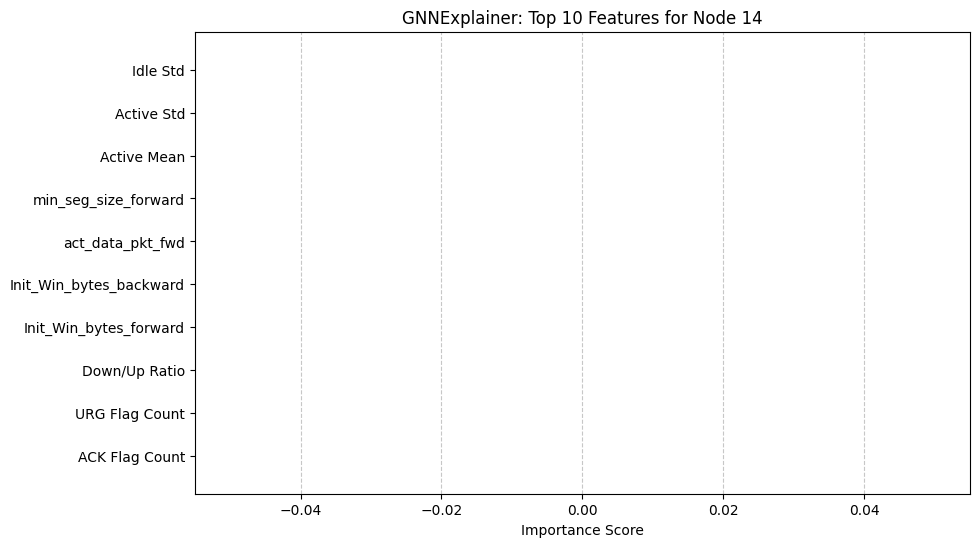

In [19]:
from torch_geometric.explain import Explainer, GNNExplainer
import matplotlib.pyplot as plt
import numpy as np

# 6. Explainability via GNNExplainer
explainer = Explainer(
    model=model,
    algorithm=GNNExplainer(epochs=200),
    explanation_type='model',
    node_mask_type='attributes',
    edge_mask_type='object',
    model_config=dict(
        mode='multiclass_classification',
        task_level='node',
        return_type='raw',
    )
)

# Explain a random test node
test_indices = torch.where(data.test_mask)[0]
node_index = test_indices[0].item()
explanation = explainer(data.x, data.edge_index, index=node_index)

# Extract attribute importance
if explanation.node_mask.dim() == 2:
    # Use mean across nodes if it returned a full mask, otherwise index it
    local_importances = explanation.node_mask[0].abs().cpu().numpy()
else:
    local_importances = explanation.node_mask.abs().cpu().numpy().flatten()

# Check if scores are non-zero to diagnose empty plots
print(f'Generated explanation for node {node_index}')
print(f'Max importance score: {local_importances.max():.6f}')

# Get top 10 features
indices = np.argsort(local_importances)[-10:]

plt.figure(figsize=(10, 6))
plt.barh(range(len(indices)), local_importances[indices], color='teal')
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel('Importance Score')
plt.title(f'GNNExplainer: Top 10 Features for Node {node_index}')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

### 7. Comprehensive Visualization & Interpretability Suite
This section aggregates the diagnostic plots and explainability outputs to evaluate the CyberSAGE model's performance and decision-making process.

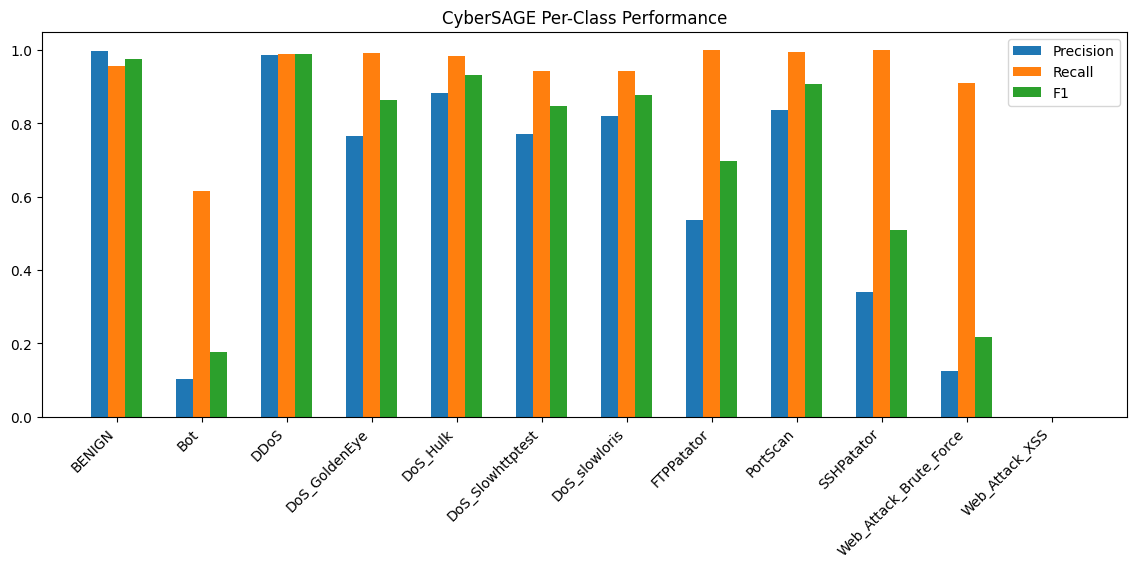

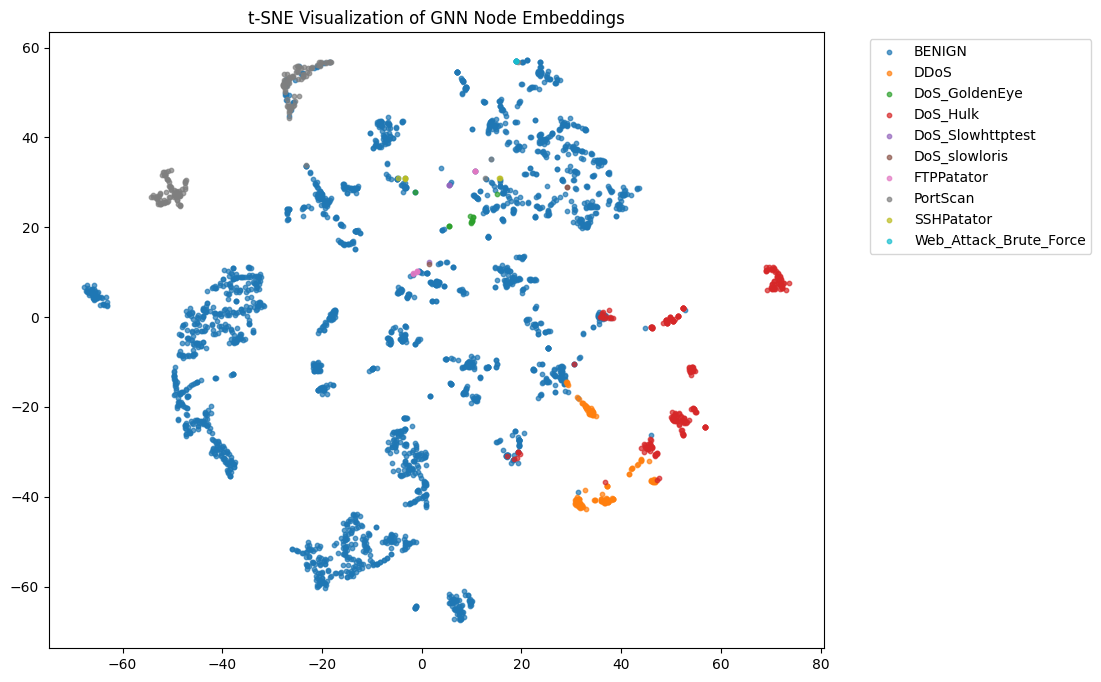

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import precision_recall_fscore_support
from sklearn.manifold import TSNE
import pandas as pd

# --- 1. Per-Class Metrics Bar Chart ---
p, r, f, s = precision_recall_fscore_support(true, pred, labels=np.unique(true), zero_division=0)

plt.figure(figsize=(14, 5))
x_axis = np.arange(len(le.classes_))
plt.bar(x_axis - 0.2, p, 0.2, label='Precision')
plt.bar(x_axis, r, 0.2, label='Recall')
plt.bar(x_axis + 0.2, f, 0.2, label='F1')
plt.xticks(x_axis, le.classes_, rotation=45, ha='right')
plt.title('CyberSAGE Per-Class Performance')
plt.legend()
plt.show()

# --- 2. t-SNE of GNN Embeddings ---
model.eval()
with torch.no_grad():
    # Using the residual sum before the classifier head as embeddings
    s = model.skip(data.x)
    x_emb = F.relu(model.bn1(model.conv1(data.x, data.edge_index)))
    x_emb = F.relu(model.bn2(model.conv2(x_emb, data.edge_index)))
    embeddings = (x_emb + s).cpu().numpy()

test_idx = torch.where(data.test_mask)[0].cpu().numpy()
sample_size = min(3000, len(test_idx))
subset = np.random.choice(test_idx, sample_size, replace=False)

tsne = TSNE(n_components=2, perplexity=30, random_state=42)
emb_2d = tsne.fit_transform(embeddings[subset])

plt.figure(figsize=(10, 8))
for i, label in enumerate(le.classes_):
    mask = data.y[subset].cpu().numpy() == i
    if mask.any():
        plt.scatter(emb_2d[mask, 0], emb_2d[mask, 1], label=label, s=10, alpha=0.7)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.title('t-SNE Visualization of GNN Node Embeddings')
plt.show()

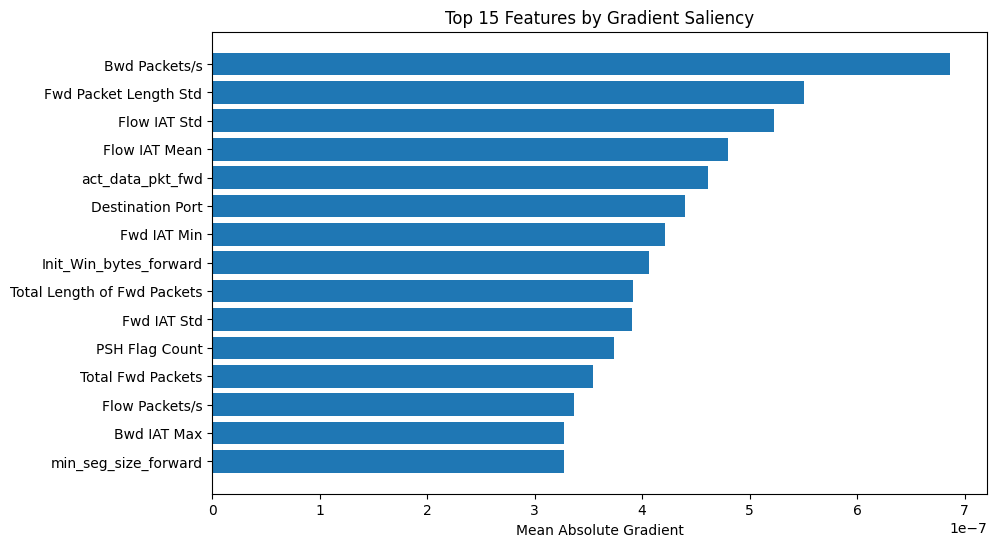

In [21]:
# --- 3. Feature Importance (Gradient Saliency) ---
model.train() # Enable gradient tracking
data.x.requires_grad = True
out = model(data.x, data.edge_index)
loss = F.cross_entropy(out[data.train_mask], data.y[data.train_mask])
loss.backward()

importances = data.x.grad.abs().mean(dim=0).cpu().numpy()
indices = np.argsort(importances)[-15:]

plt.figure(figsize=(10, 6))
plt.barh(range(len(indices)), importances[indices])
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.title('Top 15 Features by Gradient Saliency')
plt.xlabel('Mean Absolute Gradient')
plt.show()

  0%|          | 0/50 [00:00<?, ?it/s]

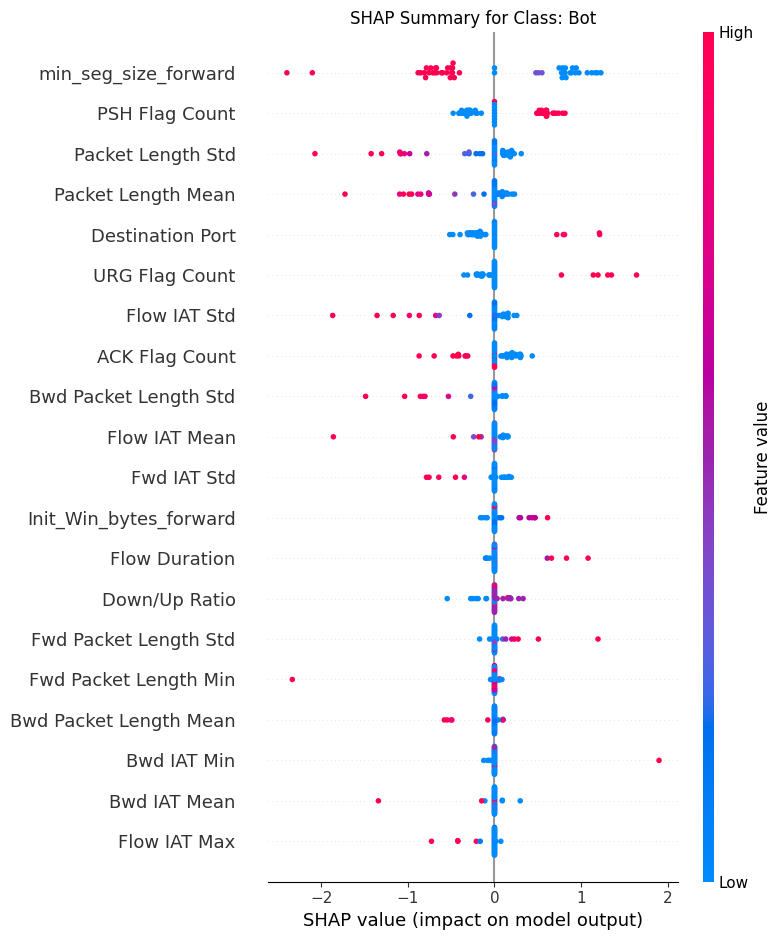

In [25]:
import shap
import numpy as np
import torch

# --- 4. SHAP Global Explanation ---
background = data.x[torch.where(data.train_mask)[0][:100]].detach().cpu().numpy()
test_subset = data.x[torch.where(data.test_mask)[0][:50]].detach().cpu().numpy()

def model_predict(x_in):
    model.eval()
    tmp_x = torch.tensor(x_in, dtype=torch.float32).to(device)
    with torch.no_grad():
        # Pass isolated nodes to evaluate feature-level contribution
        res = model(tmp_x, torch.zeros((2,0), dtype=torch.long).to(device))
    return res.cpu().numpy()

explainer_shap = shap.KernelExplainer(model_predict, background)
# Computing SHAP values for 50 samples
shap_results = explainer_shap.shap_values(test_subset, nsamples=100)

# Handle different SHAP output formats (list vs 3D array)
class_to_plot = 1 if len(le.classes_) > 1 else 0
if isinstance(shap_results, list):
    shap_val_class = shap_results[class_to_plot]
else:
    # If it's a 3D array [samples, features, classes], transpose/index accordingly
    # SHAP KernelExplainer usually returns [samples, features, classes] or a list of [samples, features]
    if len(shap_results.shape) == 3:
        shap_val_class = shap_results[:, :, class_to_plot]
    else:
        shap_val_class = shap_results

plt.figure(figsize=(10, 6))
plt.title(f"SHAP Summary for Class: {le.classes_[class_to_plot]}")
shap.summary_plot(shap_val_class, test_subset, feature_names=feature_names, show=True)

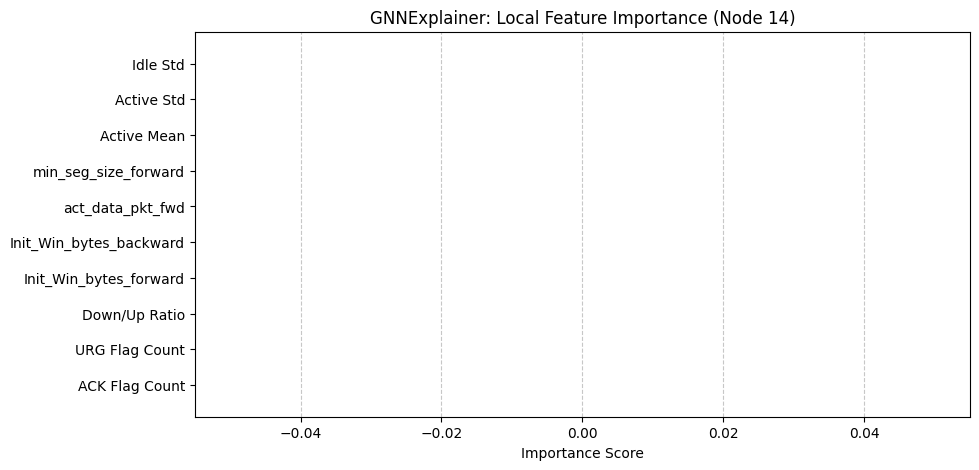

In [27]:
# --- 5. Corrected GNNExplainer Feature Visualization ---
# The error was caused by feat_idx containing node indices instead of feature indices.
# We ensure we are looking at the attribute (feature) mask specifically.

# Ensure we extract the feature importance part of the mask
# GNNExplainer node_mask can be (1, num_features) or (num_nodes, num_features)
if explanation.node_mask.dim() == 2:
    # If it's a 2D mask, the first dimension is often the node or a dummy batch dim
    # We take the absolute mean or the specific row for the features
    raw_mask = explanation.node_mask[0].cpu().numpy()
else:
    raw_mask = explanation.node_mask.cpu().numpy().flatten()

# Ensure the mask length matches our feature count
if len(raw_mask) > len(feature_names):
    raw_mask = raw_mask[:len(feature_names)]

feat_idx = np.argsort(raw_mask)[-10:]

plt.figure(figsize=(10, 5))
plt.barh(range(10), raw_mask[feat_idx], color='teal')
plt.yticks(range(10), [feature_names[i] for i in feat_idx])
plt.title(f'GNNExplainer: Local Feature Importance (Node {node_index})')
plt.xlabel('Importance Score')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()